# Epistemic Credibility in Online Conspiracy Communities
## Master Analysis Pipeline

**Research Question:** What markers of epistemic credibility do participants in r/conspiracy treat as legitimate, as indexed by community engagement signals?

**Corpus:** Complete comment and submission archive of r/conspiracy (~40M raw comments, ~21M usable after length filter)

### Research map

| Section | Question | Key outputs |
|---|---|---|
| **1–2** | What epistemic language is present, and does it predict upvotes? | `lexical_scores_full.parquet` (5 core dims) |
| **3** | How are sources attributed syntactically? | `spacy_attributed_comments.parquet` |
| **4–5** | Which cited domains and post types get rewarded? | domain tables, post metadata |
| **6–7** | How do threads and years differ in epistemic style? | `master_thread_synthesis.parquet` |
| **8** | Human validation loop | `human_labels_active_learning.csv` |
| **9.1** | Extended 11-dimension lexicon (DuckDB regex) | `empath_scores_full.parquet` |
| **9.2** | Semantic topic structure of high-upvote comments | `bertopic_model`, `high_upvote_with_topics.parquet` |
| **9.3** | Epistemic typing of cited domains | `domain_epistemic_performance.csv` |
| **9.4–9.6** | Insider filtering, tier signatures, case typologies | insider vote baselines |
| **9.7** | Cross-post audit + demographic thread lifespan | `cross_post_audit_results.csv`, `api_audit_sampling_1k.parquet` |
| **9.8** | Lexical insider score / community convergence | `lexical_baseline_*.csv`, `lexical_keyness_*.csv` |
| **9.9** | Epistemic strategy vs social capital | correlation heatmaps, archetype plots |
| **9.10** | Full-Corpus Scale-Up & Maverick Authority Analysis | correlation matrices, engagement decile regressions, localized maverick list |

Most cells below **read pre-computed parquet/CSV files** via DuckDB. Heavy one-time pipelines (full-corpus scoring, BERTopic fit, Arctic Shift API sweep) are kept as reference but need not be re-run.

---


## 0. Imports and File Paths

In [1]:
import time

In [2]:
import re
import os
import duckdb
import pandas as pd
import numpy as np
import requests
from tqdm import tqdm
from IPython.display import HTML, display

# --- File paths (all outputs live under BASE) ---
BASE = '/Users/nash/Projects/ConspiracyComments/data/processed/'
RAW_COMMENTS = "/Users/nash/Projects/ConspiracyComments/data/raw/r_conspiracy_comments*.jsonl*"
RAW_POSTS = "/Users/nash/Projects/ConspiracyComments/data/raw/r_conspiracy_posts*.jsonl*"
COMMENTS_GLOB = RAW_COMMENTS  # alias kept for the Section 9.7-9.8 queries
LEXICAL = BASE + 'lexical_scores_full.parquet'
EMPATH = BASE + 'empath_scores_full.parquet'
SPACY = BASE + 'spacy_attributed_comments.parquet'
SYNTHESIS = BASE + 'master_thread_synthesis.parquet'
LABELS = BASE + 'human_labels_active_learning.csv'

pd.set_option('display.max_colwidth', None)

# Single DuckDB connection reused across the notebook
con = duckdb.connect()

display(HTML("""
<style>
    .dataframe td {
        white-space: normal !important;
        word-wrap: break-word;
        max-width: 300px;
    }
    .dataframe th { max-width: 300px; }
</style>
"""))
print("Ready.")


Ready.


---
## 1. Corpus Overview

Basic counts and sanity checks on the corpus.

In [4]:
# Total raw comments & corpus stats
import os
import json

metadata_cache = BASE + 'corpus_metadata.json'
if os.path.exists(metadata_cache):
    with open(metadata_cache, 'r') as f:
        meta = json.load(f)
    raw = meta['raw_comments']
    usable = meta['usable_comments']
    threads = meta['threads']
    print("Loaded corpus stats from cache.")
else:
    print("Cache not found. Scanning raw comments (this will take a while)...\n")
    raw = con.execute(f"""
        SELECT COUNT(*) as total_raw
        FROM read_json_auto('{RAW_COMMENTS}', union_by_name=true, ignore_errors=true)
        WHERE body IS NOT NULL AND body != '[deleted]' AND body != '[removed]'
    """).fetchone()[0]

    usable = con.execute(f"SELECT COUNT(*) FROM '{LEXICAL}'").fetchone()[0]
    threads = con.execute(f"SELECT COUNT(*) FROM '{SYNTHESIS}'").fetchone()[0]
    
    with open(metadata_cache, 'w') as f:
        json.dump({'raw_comments': raw, 'usable_comments': usable, 'threads': threads}, f)

print(f"Raw usable comments (no length filter): {raw:,}")
print(f"Lexically scored comments (length > 100 chars): {usable:,}")
print(f"Threads in master synthesis: {threads:,}")


Loaded corpus stats from cache.
Raw usable comments (no length filter): 39,988,660
Lexically scored comments (length > 100 chars): 21,408,577
Threads in master synthesis: 888,846


---
## 2. Lexical Scoring Pipeline

Five dimensions scored via SQL LIKE pattern matching across all 21M comments.
Scores reflect **presence** of category vocabulary (binary per term, summed).

| Dimension | What it captures |
|---|---|
| `hedge_count` | Epistemic uncertainty — *maybe, apparently, I think, probably* |
| `certainty_count` | Strong assertion — *proven, obviously, the truth is, wake up* |
| `evidence_count` | Evidence appeals — *according to, peer-reviewed, data shows, http* |
| `authority_count` | Authority appeals — *expert, scientist, government, CDC, FBI* |
| `rhetorical_count` | Rhetorical moves — *follow the money, sheeple, red pill, connect the dots* |

In [5]:
# Score distributions across corpus
print(con.execute(f"""
    SELECT 
        AVG(hedge_count) as avg_hedge,
        AVG(certainty_count) as avg_certainty,
        AVG(evidence_count) as avg_evidence,
        AVG(authority_count) as avg_authority,
        AVG(rhetorical_count) as avg_rhetorical,
        MAX(hedge_count) as max_hedge,
        MAX(certainty_count) as max_certainty,
        MAX(evidence_count) as max_evidence,
        MAX(authority_count) as max_authority,
        MAX(rhetorical_count) as max_rhetorical
    FROM '{LEXICAL}'
""").df().to_string())

   avg_hedge  avg_certainty  avg_evidence  avg_authority  avg_rhetorical  max_hedge  max_certainty  max_evidence  max_authority  max_rhetorical
0    0.14382       0.050698      0.215923         0.1083        0.344293          8              5             9              8               5


In [6]:
# Lexical scores vs upvotes — does epistemic style predict community reward?
print(con.execute(f"""
    SELECT 
        upvote_tier,
        COUNT(*) as n,
        ROUND(AVG(hedge_count), 3) as avg_hedge,
        ROUND(AVG(certainty_count), 3) as avg_certainty,
        ROUND(AVG(evidence_count), 3) as avg_evidence,
        ROUND(AVG(authority_count), 3) as avg_authority,
        ROUND(AVG(rhetorical_count), 3) as avg_rhetorical
    FROM (
        SELECT *,
            CASE 
                WHEN upvotes < 0 THEN 'negative'
                WHEN upvotes = 0 THEN 'zero'
                WHEN upvotes BETWEEN 1 AND 5 THEN 'low'
                WHEN upvotes BETWEEN 6 AND 50 THEN 'medium'
                WHEN upvotes > 50 THEN 'high'
            END AS upvote_tier
        FROM '{LEXICAL}'
    )
    GROUP BY upvote_tier
    ORDER BY 
        CASE upvote_tier 
            WHEN 'negative' THEN 1 WHEN 'zero' THEN 2 
            WHEN 'low' THEN 3 WHEN 'medium' THEN 4 WHEN 'high' THEN 5 
        END
""").df().to_string())

  upvote_tier         n  avg_hedge  avg_certainty  avg_evidence  avg_authority  avg_rhetorical
0    negative   1913929      0.129          0.054         0.144          0.111           0.338
1        zero   1618487      0.141          0.057         0.171          0.113           0.344
2         low  13879338      0.147          0.050         0.246          0.103           0.364
3      medium   3699036      0.142          0.051         0.165          0.123           0.282
4        high    297787      0.131          0.047         0.149          0.128           0.247


### 2.1 Lexical Scoring Validation

Manual spot-check: pull high scorers and zero-scorers-with-keywords to identify false positives and false negatives.

In [7]:
import json
import os
import pandas as pd

# --- Configuration ---
FORCE_RESAMPLE = False  # Change to True to ignore cache and query fresh samples

spot_check_cache = os.path.join(BASE, 'validation_spot_checks.csv')
count_cache = os.path.join(BASE, 'false_negative_counts.json')

dimensions = ['hedge_count', 'certainty_count', 'evidence_count', 'authority_count', 'rhetorical_count']
keyword_map = {
    'hedge_count': '%maybe%',
    'certainty_count': '%proven%',
    'evidence_count': '%according to%',
    'authority_count': '%scientist%',
    'rhetorical_count': '%wake up%'
}

# 1. FALSE NEGATIVE COUNT CACHE
if not FORCE_RESAMPLE and os.path.exists(count_cache):
    with open(count_cache, 'r') as f:
        counts = json.load(f)
    print(f"Cached False Negatives (hedge_count = 0, contains 'maybe'): {counts['maybe_count']}")
else:
    print("Querying false negative counts...")
    maybe_count = con.execute(f"""
        SELECT COUNT(*) FROM '{LEXICAL}'
        WHERE hedge_count = 0 AND lower(text) LIKE '%maybe%'
    """).fetchone()[0]
    
    with open(count_cache, 'w') as f:
        json.dump({'maybe_count': maybe_count}, f)
    print(f"False Negatives: {maybe_count}")

# 2. SPOT CHECK CACHE 
if not FORCE_RESAMPLE and os.path.exists(spot_check_cache):
    print("\nLoading cached validation samples...\n")
    df_checks = pd.read_csv(spot_check_cache)
    
    for dim in dimensions:
        print(f"\n{'='*70}\nDIMENSION: {dim} — HIGH SCORERS (score >= 3)\n{'='*70}\n")
        high_scorers = df_checks[(df_checks['dimension'] == dim) & (df_checks['type'] == 'high_scorer')]
        for _, row in high_scorers.iterrows():
            print(f"[Score: {int(row['score'])} | Upvotes: {row['upvotes']}]\n{row['text'][:400]}\n{'-'*50}")
            
        print(f"\n--- FALSE NEGATIVE CHECK: score=0 but contains keyword ---\n")
        false_negs = df_checks[(df_checks['dimension'] == dim) & (df_checks['type'] == 'false_negative')]
        for _, row in false_negs.iterrows():
            print(f"[Score: 0 | Upvotes: {row['upvotes']}]\n{row['text'][:400]}\n{'-'*50}")

else:
    print("\nQuerying validation samples from database...")
    all_results = []
    
    for dim in dimensions:
        print(f"Processing {dim}...")
        
        # High Scorers 
        high_res = con.execute(f"""
            SELECT '{dim}' as dimension, 'high_scorer' as type, {dim} as score, upvotes, text
            FROM '{LEXICAL}'
            WHERE {dim} >= 3
            ORDER BY RANDOM()
            LIMIT 5
        """).df()
        all_results.append(high_res)
        
        # False Negatives 
        false_res = con.execute(f"""
            SELECT '{dim}' as dimension, 'false_negative' as type, {dim} as score, upvotes, text
            FROM '{LEXICAL}'
            WHERE {dim} = 0 AND lower(text) LIKE '{keyword_map[dim]}'
            ORDER BY RANDOM()
            LIMIT 3
        """).df()
        all_results.append(false_res)
        
    df_checks = pd.concat(all_results, ignore_index=True)
    df_checks.to_csv(spot_check_cache, index=False)
    print("\nValidation samples cached successfully. They will print immediately now.")
    
    for dim in dimensions:
        print(f"\n{'='*70}\nDIMENSION: {dim} — HIGH SCORERS (score >= 3)\n{'='*70}\n")
        high_scorers = df_checks[(df_checks['dimension'] == dim) & (df_checks['type'] == 'high_scorer')]
        for _, row in high_scorers.iterrows():
            print(f"[Score: {int(row['score'])} | Upvotes: {row['upvotes']}]\n{row['text'][:400]}\n{'-'*50}")
            
        print(f"\n--- FALSE NEGATIVE CHECK: score=0 but contains keyword ---\n")
        false_negs = df_checks[(df_checks['dimension'] == dim) & (df_checks['type'] == 'false_negative')]
        for _, row in false_negs.iterrows():
            print(f"[Score: 0 | Upvotes: {row['upvotes']}]\n{row['text'][:400]}\n{'-'*50}")

Cached False Negatives (hedge_count = 0, contains 'maybe'): 0

Loading cached validation samples...


DIMENSION: hedge_count — HIGH SCORERS (score >= 3)

[Score: 3 | Upvotes: 7.0]
Someone told me that I believe in "fringe conspiracy theories" because I said the CIA *probably* had a hand in Venezuela's decline (the same guy reported my comment to the mods of /r/worldnews, who deleted it because "read a fucking book for once" is apparently a terrible insult. I only demolished his fucking post after he claimed I was ignorant...). The thing is, the CIA has had a hand in the ove
--------------------------------------------------
[Score: 3 | Upvotes: 2.0]
Shift 18 first half of title decodes to: BLACK CUBE
Shift 19 the 2nd half of the title decodes to: RED HEART

You can play with it at : https://cryptii.com/pipes/caesar-cipher

Description is not caesar i think but perhaps viginere or other polyalphabetic cipher. maybe the title is the key.
--------------------------------------------------

---
## 3. Attribution Classification (spaCy)

Stage 1: 614,888 comments filtered by attribution syntax (2.9% of corpus)  
Stage 2: spaCy dependency parsing + NER to classify attribution type

Categories map onto FACTAPPEAL annotation scheme.

In [8]:
import pandas as pd
import os
import re
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# --- Configuration ---
BASE_DIR = '/Users/nash/Projects/ConspiracyComments/data/processed/factappeal'
MODEL_CACHE_PATH = os.path.join(BASE_DIR, 'factappeal_classifier.pkl')
VEC_CACHE_PATH = os.path.join(BASE_DIR, 'factappeal_vectorizer.pkl')

def parse_fact_appeal_csv(filepath):
    """
    Reads the FactAppeal CSV structure using the correct columns:
    'sentence' (raw text) and 'annotation' (XML tagged text).
    """
    df_raw = pd.read_csv(filepath)
    parsed_data = []
    
    for _, row in df_raw.iterrows():
        annotation_text = str(row['annotation']).strip()
        clean_text = re.sub(r'<.*?>', '', annotation_text)
        
        if '<Fact_Appeal' in annotation_text or '<Source' in annotation_text:
            label = 1
        else:
            label = 0
            
        parsed_data.append({'text': clean_text, 'label': label})
        
    return pd.DataFrame(parsed_data)

# --- Checkpoint Verification ---
if os.path.exists(MODEL_CACHE_PATH) and os.path.exists(VEC_CACHE_PATH):
    print("Loading pre-trained baseline classifier and vectorizer from disk cache...")
    classifier = joblib.load(MODEL_CACHE_PATH)
    vectorizer = joblib.load(VEC_CACHE_PATH)
    print("Pipeline ready.")
    
else:
    print("Cache missing. Re-building and training the optimal baseline model...")
    
    # 1. Load and parse the files
    print("Parsing train, val, and test splits...")
    train_df = parse_fact_appeal_csv(os.path.join(BASE_DIR, 'train.csv'))
    val_df = parse_fact_appeal_csv(os.path.join(BASE_DIR, 'val.csv'))
    test_df = parse_fact_appeal_csv(os.path.join(BASE_DIR, 'test.csv'))

    # 2. Extract features
    print("Vectorizing structural text features...")
    vectorizer = TfidfVectorizer(
        analyzer='word',
        ngram_range=(1, 3),
        max_features=15000,
        sublinear_tf=True
    )

    X_train = vectorizer.fit_transform(train_df['text'])
    y_train = train_df['label']

    X_val = vectorizer.transform(val_df['text'])
    y_val = val_df['label']

    X_test = vectorizer.transform(test_df['text'])
    y_test = test_df['label']

    # 3. Train the Local Classifier
    print("Training classifier locally...")
    classifier = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    classifier.fit(X_train, y_train)

    # 4. Serialize out to disk so you never have to train it again
    print("Saving pipeline components to cache...")
    joblib.dump(classifier, MODEL_CACHE_PATH)
    joblib.dump(vectorizer, VEC_CACHE_PATH)

    # 5. Evaluate on Validation Set
    val_preds = classifier.predict(X_val)
    print("\n=== Validation Set Performance ===")
    print(classification_report(y_val, val_preds))

    # 6. Final Evaluation on Unseen Test Set
    test_preds = classifier.predict(X_test)
    print("\n=== Final Test Set Performance ===")
    print(classification_report(y_test, test_preds))

Loading pre-trained baseline classifier and vectorizer from disk cache...
Pipeline ready.


In [9]:
import pandas as pd
import os
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# --- Configuration ---
BASE_DIR = '/Users/nash/Projects/ConspiracyComments/data/processed/factappeal'

def parse_fact_appeal_csv(filepath):
    """
    Reads the FactAppeal CSV structure using the correct columns:
    'sentence' (raw text) and 'annotation' (XML tagged text).
    """
    df_raw = pd.read_csv(filepath)
    
    parsed_data = []
    
    # Iterate through the rows using the exact columns from the README
    for _, row in df_raw.iterrows():
        annotation_text = str(row['annotation']).strip()
        
        # 1. Clean out all XML tags to get raw text for machine learning features
        clean_text = re.sub(r'<.*?>', '', annotation_text)
        
        # 2. Define target label: Look for any form of Fact_Appeal or Source tags
        # If the string contains an appeal or source tag, it's an attribution sentence (1)
        if '<Fact_Appeal' in annotation_text or '<Source' in annotation_text:
            label = 1
        else:
            label = 0
            
        parsed_data.append({'text': clean_text, 'label': label})
        
    return pd.DataFrame(parsed_data)

# 1. Load and parse the files using the exact names from the README
print("Parsing train, val, and test splits...")
train_df = parse_fact_appeal_csv(os.path.join(BASE_DIR, 'train.csv'))
val_df = parse_fact_appeal_csv(os.path.join(BASE_DIR, 'val.csv'))
test_df = parse_fact_appeal_csv(os.path.join(BASE_DIR, 'test.csv'))

# 2. Extract features using word n-grams (1 to 3 words long)
# This captures structural sequences like "said that", "according to", or "criticized the"
print("Vectorizing structural text features...")
vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 3),
    max_features=15000,
    sublinear_tf=True # Smooths out term frequency scaling
)

X_train = vectorizer.fit_transform(train_df['text'])
y_train = train_df['label']

X_val = vectorizer.transform(val_df['text'])
y_val = val_df['label']

X_test = vectorizer.transform(test_df['text'])
y_test = test_df['label']

# 3. Train the Local Classifier
print("Training classifier locally...")
classifier = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
classifier.fit(X_train, y_train)

# 4. Evaluate on Validation Set
val_preds = classifier.predict(X_val)
print("\n=== Validation Set Performance ===")
print(classification_report(y_val, val_preds))

# 5. Final Evaluation on Unseen Test Set
test_preds = classifier.predict(X_test)
print("\n=== Final Test Set Performance ===")
print(classification_report(y_test, test_preds))

Parsing train, val, and test splits...
Vectorizing structural text features...
Training classifier locally...

=== Validation Set Performance ===
              precision    recall  f1-score   support

           0       0.87      0.89      0.88       332
           1       0.74      0.72      0.73       151

    accuracy                           0.83       483
   macro avg       0.81      0.80      0.80       483
weighted avg       0.83      0.83      0.83       483


=== Final Test Set Performance ===
              precision    recall  f1-score   support

           0       0.87      0.89      0.88       332
           1       0.74      0.72      0.73       151

    accuracy                           0.83       483
   macro avg       0.81      0.80      0.80       483
weighted avg       0.83      0.83      0.83       483



In [10]:
con.execute(f"DESCRIBE SELECT * FROM read_parquet('{EMPATH}')").fetchall()

[('id', 'VARCHAR', 'YES', None, None, None),
 ('author', 'VARCHAR', 'YES', None, None, None),
 ('upvotes', 'DOUBLE', 'YES', None, None, None),
 ('controversiality', 'BIGINT', 'YES', None, None, None),
 ('parent_id', 'VARCHAR', 'YES', None, None, None),
 ('link_id', 'VARCHAR', 'YES', None, None, None),
 ('created_utc', 'BIGINT', 'YES', None, None, None),
 ('char_length', 'BIGINT', 'YES', None, None, None),
 ('has_link', 'INTEGER', 'YES', None, None, None),
 ('text', 'VARCHAR', 'YES', None, None, None),
 ('evidence_count', 'INTEGER', 'YES', None, None, None),
 ('adversarial_count', 'INTEGER', 'YES', None, None, None),
 ('hedge_count', 'INTEGER', 'YES', None, None, None),
 ('certainty_count', 'INTEGER', 'YES', None, None, None),
 ('alt_authority_count', 'INTEGER', 'YES', None, None, None),
 ('intuitive_count', 'INTEGER', 'YES', None, None, None),
 ('pattern_count', 'INTEGER', 'YES', None, None, None),
 ('meta_count', 'INTEGER', 'YES', None, None, None),
 ('demand_count', 'INTEGER', 'YES',

In [11]:
# STREAMING_CHUNK: Executing high-signal query filters...
import duckdb
import pandas as pd
import os

con = duckdb.connect()
FILTERED_CACHE = os.path.join(BASE, 'filtered_candidates.parquet')

# Build the SQL query using your target filters
# We wrap it in a COPY command to write directly to Parquet
query = f"""
    COPY (
        SELECT id, author, text 
        FROM read_parquet('{EMPATH}')
        WHERE evidence_count > 0 
           OR has_link = 1 
           OR alt_authority_count > 0 
           OR quantitative_count > 0
    ) TO '{FILTERED_CACHE}' (FORMAT PARQUET, COMPRESSION 'zstd')
"""

if not os.path.exists(FILTERED_CACHE):
    print("Filtering 21M corpus and caching to Parquet...")
    # DuckDB writes the result straight to disk, bypassing RAM limitations
    con.execute(query)
else:
    print("Loading filtered subset from Parquet cache...")

# Load into Pandas memory for the upcoming annotation pipeline
filtered_df = pd.read_parquet(FILTERED_CACHE)
print(f"Original rows: 21,000,000 | Filtered rows: {len(filtered_df):,}")

Loading filtered subset from Parquet cache...
Original rows: 21,000,000 | Filtered rows: 4,781,460


In [ ]:
import pandas as pd
import re
import joblib
import os
import glob

# --- 1. Load Pre-trained Models & Data ---
MODEL_CACHE_PATH = os.path.join(BASE_DIR, 'factappeal_classifier.pkl')
VEC_CACHE_PATH = os.path.join(BASE_DIR, 'factappeal_vectorizer.pkl')

print("Loading vectorizer and classifier...")
vectorizer = joblib.load(VEC_CACHE_PATH)
classifier = joblib.load(MODEL_CACHE_PATH)

# Point back to the main processed directory where DuckDB saved the file
BASE = '/Users/nash/Projects/ConspiracyComments/data/processed/'
FILTERED_CACHE = os.path.join(BASE, 'filtered_candidates.parquet')
run_df = pd.read_parquet(FILTERED_CACHE)

# --- 2. Setup Chunking & Checkpoints ---
CHUNK_SIZE = 5000  # Process 5,000 comments at a time
OUTPUT_DIR = os.path.join(BASE_DIR, 'annotated_chunks')
os.makedirs(OUTPUT_DIR, exist_ok=True)

def split_into_sentences(text):
    if not text or not isinstance(text, str):
        return []
    sentences = re.split(r'(?<=[.!?])\s+', text)
    return [s.strip() for s in sentences if s.strip()]

print(f"Starting batch inference on {len(run_df):,} comments...")

# --- 3. Execute in Batches ---
for start_idx in range(0, len(run_df), CHUNK_SIZE):
    end_idx = min(start_idx + CHUNK_SIZE, len(run_df))
    chunk_file = os.path.join(OUTPUT_DIR, f"chunk_{start_idx}_to_{end_idx}.parquet")
    
    # CHECKPOINT: Skip if this chunk is already done
    if os.path.exists(chunk_file):
        print(f"Skipping {start_idx} to {end_idx} (already cached)")
        continue
        
    print(f"Processing rows {start_idx:,} to {end_idx:,}...")
    chunk = run_df.iloc[start_idx:end_idx].copy()
    
    all_sentences = []
    sentence_to_comment_map = []
    
    # A. Flatten all sentences for batch vectorization
    for i, text in enumerate(chunk['text']):
        sentences = split_into_sentences(text)
        for s in sentences:
            all_sentences.append(s)
            sentence_to_comment_map.append(i) # Tracks which comment this sentence belongs to
            
    if not all_sentences:
        chunk['annotated_body'] = ""
        chunk['contains_attribution_flag'] = 0
        chunk.to_parquet(chunk_file)
        continue
        
    # B. Vectorize and Predict ALL sentences in this chunk AT ONCE
    # (This eliminates the scikit-learn loop overhead)
    X_batch = vectorizer.transform(all_sentences)
    predictions = classifier.predict(X_batch)
    
    # C. Reassemble the tagged sentences back into their original comments
    annotated_bodies = [[] for _ in range(len(chunk))]
    has_attr = [0 for _ in range(len(chunk))]
    
    for s, pred, c_idx in zip(all_sentences, predictions, sentence_to_comment_map):
        if pred == 1:
            annotated_bodies[c_idx].append(f"<Fact_With_Attribution>{s}</Fact_With_Attribution>")
            has_attr[c_idx] = 1
        else:
            annotated_bodies[c_idx].append(f"<Fact_No_Appeal>{s}</Fact_No_Appeal>")
            
    chunk['annotated_body'] = [" ".join(lst) for lst in annotated_bodies]
    chunk['contains_attribution_flag'] = has_attr
    
    # D. Save the completed chunk to disk
    chunk.to_parquet(chunk_file, compression='zstd')

print("\nAll chunks processed! Combining into final dataset...")

# --- 4. Combine Chunks ---
chunk_files = glob.glob(os.path.join(OUTPUT_DIR, "chunk_*.parquet"))
final_df = pd.concat([pd.read_parquet(f) for f in chunk_files], ignore_index=True)

FINAL_OUTPUT_PATH = os.path.join(BASE_DIR, 'annotated_candidates_final.parquet')
final_df.to_parquet(FINAL_OUTPUT_PATH, compression='zstd')

print(f"Done. Saved final annotated dataset ({len(final_df):,} rows) to {FINAL_OUTPUT_PATH}")

Loading vectorizer and classifier...
Starting batch inference on 4,781,460 comments...
Processing rows 0 to 5,000...
Processing rows 5,000 to 10,000...
Processing rows 10,000 to 15,000...
Processing rows 15,000 to 20,000...
Processing rows 20,000 to 25,000...
Processing rows 25,000 to 30,000...
Processing rows 30,000 to 35,000...
Processing rows 35,000 to 40,000...
Processing rows 40,000 to 45,000...
Processing rows 45,000 to 50,000...
Processing rows 50,000 to 55,000...
Processing rows 55,000 to 60,000...
Processing rows 60,000 to 65,000...
Processing rows 65,000 to 70,000...
Processing rows 70,000 to 75,000...
Processing rows 75,000 to 80,000...
Processing rows 80,000 to 85,000...
Processing rows 85,000 to 90,000...
Processing rows 90,000 to 95,000...
Processing rows 95,000 to 100,000...
Processing rows 100,000 to 105,000...
Processing rows 105,000 to 110,000...
Processing rows 110,000 to 115,000...
Processing rows 115,000 to 120,000...
Processing rows 120,000 to 125,000...
Processin

In [76]:
import duckdb
import os

con = duckdb.connect()
FINAL_OUTPUT_PATH = os.path.join(BASE_DIR, 'annotated_candidates_final.parquet')

# 1. Quick distribution check: How many comments actually got an attribution flag?
print("=== ATTRIBUTION FLAG DISTRIBUTION ===")
print(con.execute(f"""
    SELECT contains_attribution_flag, COUNT(*) as count
    FROM read_parquet('{FINAL_OUTPUT_PATH}')
    GROUP BY contains_attribution_flag
""").df())

# 2. Spot check: Grab 3 examples where an attribution was successfully caught
print("\n=== SAMPLE DETECTED ATTRIBUTIONS ===")
samples = con.execute(f"""
    SELECT author, annotated_body 
    FROM read_parquet('{FINAL_OUTPUT_PATH}')
    WHERE contains_attribution_flag = 1
    LIMIT 3
""").df()

for i, row in samples.iterrows():
    print(f"\nAuthor: {row['author']}")
    print(f"Body: {row['annotated_body'][:500]}...")
    print("-" * 60)

=== ATTRIBUTION FLAG DISTRIBUTION ===
   contains_attribution_flag    count
0                          0  3886014
1                          1   895446

=== SAMPLE DETECTED ATTRIBUTIONS ===

Author: Fearless-Past9652
Body: <Fact_With_Attribution>He said it himself:

https://www.theguardian.com/technology/2022/aug/06/andrew-tate-violent-misogynistic-world-of-tiktok-new-star</Fact_With_Attribution>...
------------------------------------------------------------

Author: a_human-being
Body: <Fact_No_Appeal>SS:

  e year on as the war in Ukraine continues, when voices everywhere should be calling for ceasefire and peace,
this resolution is driving us in the opposite direction, so i proudly voted against it.</Fact_No_Appeal> <Fact_No_Appeal>It peddles the latest lie that this is not now about defending Ukraine.</Fact_No_Appeal> <Fact_No_Appeal>It's about "Ukraine must win".</Fact_No_Appeal> <Fact_No_Appeal>What does that even mean?</Fact_No_Appeal> <Fact_With_Attribution>Last Apri...
------

In [78]:
import duckdb
import os

BASE_DIR = '/Users/nash/Projects/ConspiracyComments/data/processed/factappeal'
INPUT_PATH = os.path.join(BASE_DIR, 'annotated_candidates_final.parquet')
CORRECTED_PATH = os.path.join(BASE_DIR, 'annotated_candidates_corrected.parquet')

con = duckdb.connect()

print("Correcting temporal false positives directly on disk...")

# This SQL regex locates any <Fact_With_Attribution> tags that wrap around 
# temporal phrases like 'last April' or explicit years, and flips them to <Appeal_Time>.
con.execute(f"""
    CREATE OR REPLACE TEMP TABLE corrected_data AS
    SELECT 
        id,
        author,
        text,
        -- Replace the XML tags for sentences containing specific time markers
        regexp_replace(
            annotated_body, 
            '<Fact_With_Attribution>([^<]*?\\b(last April|last year|in \\d{{4}})\\b[^<]*?)</Fact_With_Attribution>', 
            '<Appeal_Time>\\1</Appeal_Time>', 
            'g'
        ) AS annotated_body
    FROM read_parquet('{INPUT_PATH}');
""")

print("Recalculating clean source attribution flags...")

# Re-evaluate the boolean flag: if the text still contains a true source tag, it's a 1.
# If it only contains time tags or no-appeal tags, it becomes a 0.
con.execute(f"""
    COPY (
        SELECT 
            *,
            CASE 
                WHEN annotated_body LIKE '%<Fact_With_Attribution>%' THEN 1 
                ELSE 0 
            END AS contains_attribution_flag
        FROM corrected_data
    ) TO '{CORRECTED_PATH}' (FORMAT PARQUET, COMPRESSION 'zstd')
""")

print(f"Done! Cleaned dataset written to {CORRECTED_PATH}")

Correcting temporal false positives directly on disk...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Recalculating clean source attribution flags...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Done! Cleaned dataset written to /Users/nash/Projects/ConspiracyComments/data/processed/factappeal/annotated_candidates_corrected.parquet


In [79]:
print(con.execute(f"""
    SELECT contains_attribution_flag, COUNT(*) 
    FROM read_parquet('{CORRECTED_PATH}') 
    GROUP BY contains_attribution_flag
""").df())

   contains_attribution_flag  count_star()
0                          0       3896075
1                          1        885385


In [80]:
# Distribution of attribution classes
print(con.execute(f"""
    SELECT attribution_class, COUNT(*) as n,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as pct
    FROM '{SPACY}'
    GROUP BY attribution_class
    ORDER BY n DESC
""").df().to_string())

                attribution_class       n    pct
0   Indirect_Quote:Named_Official  139342  22.66
1              Direct_Quote:Named  134889  21.94
2      Indirect_Quote:News_Report  111579  18.15
3            No_Clear_Attribution   73014  11.87
4     Indirect_Quote:Unattributed   58581   9.53
5            Direct_Quote:Unnamed   53717   8.74
6      Indirect_Quote:Named_Other   24315   3.95
7             Direct_Quote:Expert   15072   2.45
8   Indirect_Quote:Unnamed_Expert    2722   0.44
9     Indirect_Quote:Named_Expert    1269   0.21
10  Indirect_Quote:Unnamed_Source     388   0.06


In [81]:
# Attribution class vs community engagement
print(con.execute(f"""
    SELECT 
        attribution_class,
        COUNT(*) as n,
        ROUND(AVG(upvotes), 2) as avg_upvotes,
        ROUND(MEDIAN(upvotes), 2) as median_upvotes,
        ROUND(AVG(controversiality), 3) as avg_controversy
    FROM '{SPACY}'
    GROUP BY attribution_class
    ORDER BY avg_upvotes DESC
""").df().to_string())

                attribution_class       n  avg_upvotes  median_upvotes  avg_controversy
0   Indirect_Quote:Unnamed_Source     388         7.01             2.0            0.070
1              Direct_Quote:Named  134889         6.30             2.0            0.084
2            No_Clear_Attribution   73014         5.97             2.0            0.067
3            Direct_Quote:Unnamed   53717         5.38             2.0            0.076
4      Indirect_Quote:Named_Other   24315         5.24             2.0            0.080
5      Indirect_Quote:News_Report  111579         5.06             2.0            0.073
6   Indirect_Quote:Named_Official  139342         5.03             2.0            0.074
7             Direct_Quote:Expert   15072         4.98             2.0            0.069
8   Indirect_Quote:Unnamed_Expert    2722         4.59             1.0            0.077
9     Indirect_Quote:Unattributed   58581         4.38             1.0            0.070
10    Indirect_Quote:Named_Exper

In [84]:
import duckdb
import os

con = duckdb.connect()
SPACY_CSV_PATH = '/Users/nash/Projects/ConspiracyComments/data/processed/spacy_attribution_results.csv'
NEW_PARQUET_PATH = '/Users/nash/Projects/ConspiracyComments/data/processed/factappeal/annotated_candidates_final.parquet'

print("Pulling spot-check examples for SpaCy audit...\n")

# Query the raw text from the parquet file by matching the IDs from the SpaCy CSV
audit_df = con.execute(f"""
    SELECT s.attribution_class, p.text 
    FROM read_parquet('{SPACY}') s
    JOIN read_parquet('{NEW_PARQUET_PATH}') p ON s.id = p.id
    WHERE s.attribution_class IN ('Indirect_Quote:Named_Official', 'Direct_Quote:Named')
    USING SAMPLE 10;
""").df()

for i, row in audit_df.iterrows():
    print(f"[{row['attribution_class']}]")
    print(f"Text: {row['text'][:350]}...\n")
    print("-" * 60)

Pulling spot-check examples for SpaCy audit...

[Indirect_Quote:Named_Official]
Text: This is a big one you are asking me here. It such a long process. I am 33 years old (Quebec City, french, which is why I do a lots of mistakes) now and I can say that I was always pretty good when it comes to perceptions and seeing things. I always was some kind of outcast and always refused authority by nature because at a young age I always saw t...

------------------------------------------------------------
[Indirect_Quote:Named_Official]
Text: Headline is *a little* misleading, they didn't track phones, per se, they bought data from one of the dozens of cellphone data brokers.

See, the issue here is that this data exists at all and it's purchasable by any group. I feel like the CDC are the least scary people buying this data. And from the looks of it, they used it for medical-related re...

------------------------------------------------------------
[Indirect_Quote:Named_Official]
Text: Around

In [85]:
import duckdb
import pandas as pd

con = duckdb.connect()
SPACY_CSV_PATH = '/Users/nash/Projects/ConspiracyComments/data/processed/spacy_attribution_results.csv'

print("Pulling stratified sample for SpaCy precision audit...\n")

audit_df = con.execute(f"""
    WITH sampled AS (
        SELECT 
            attribution_class, 
            text,
            ROW_NUMBER() OVER (PARTITION BY attribution_class ORDER BY RANDOM()) as rn
        FROM read_parquet('{SPACY}')
        WHERE attribution_class IN (
            'Indirect_Quote:Named_Expert', 
            'Direct_Quote:Expert', 
            'Indirect_Quote:Unnamed_Source', 
            'Indirect_Quote:Named_Official'
        )
    )
    SELECT attribution_class, text 
    FROM sampled 
    WHERE rn <= 15;
""").df()

# Export this to a quick CSV so you can manually score it
AUDIT_OUTPUT = '/Users/nash/Projects/ConspiracyComments/data/processed/spacy_audit_scratchpad.csv'
audit_df.to_csv(AUDIT_OUTPUT, index=False)

print(f"Audit scratchpad saved to: {AUDIT_OUTPUT}")
print("Open this in Excel/Numbers, add a 'True_Positive' column (1 or 0), and tally the scores.")

Pulling stratified sample for SpaCy precision audit...

Audit scratchpad saved to: /Users/nash/Projects/ConspiracyComments/data/processed/spacy_audit_scratchpad.csv
Open this in Excel/Numbers, add a 'True_Positive' column (1 or 0), and tally the scores.


In [86]:
import duckdb
import os

VALIDATED_PARQUET_PATH = '/Users/nash/Projects/ConspiracyComments/data/processed/factappeal/annotated_candidates_final.parquet'
FINAL_ENRICHED_PATH = '/Users/nash/Projects/ConspiracyComments/data/processed/research_corpus_enriched.parquet'

con = duckdb.connect()

print("Synthesizing validated attributions with SpaCy metadata...")

con.execute(f"""
    COPY (
        SELECT 
            p.*,
            -- ONLY include SpaCy class if the FactAppeal model confirmed an attribution
            CASE 
                WHEN p.contains_attribution_flag = 1 THEN s.attribution_class 
                ELSE 'None' 
            END AS validated_spacy_type
        FROM read_parquet('{VALIDATED_PARQUET_PATH}') p
        LEFT JOIN read_parquet('{SPACY}') s 
            ON p.id = s.id
    ) TO '{FINAL_ENRICHED_PATH}' (FORMAT PARQUET, COMPRESSION 'zstd')
""")

print(f"Success! Enriched dataset saved to {FINAL_ENRICHED_PATH}")

Synthesizing validated attributions with SpaCy metadata...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Success! Enriched dataset saved to /Users/nash/Projects/ConspiracyComments/data/processed/research_corpus_enriched.parquet


In [88]:

con = duckdb.connect()

print("=== Validated SpaCy Type Distribution ===")
# This shows how many SpaCy labels were kept (the ones flagged by the model)
# vs how many were discarded (marked as 'None')
dist = con.execute(f"""
    SELECT validated_spacy_type, COUNT(*) as n
    FROM read_parquet('{FINAL_ENRICHED_PATH}')
    GROUP BY validated_spacy_type
    ORDER BY n DESC
""").df()
print(dist)

print("\n=== Spot-Check Examples (Flagged as Fact-Appeal + SpaCy Type) ===")
# This pulls 10 random samples of successful attributions 
# that also have a specific SpaCy typology assigned
spot_checks = con.execute(f"""
    SELECT validated_spacy_type, text
    FROM read_parquet('{FINAL_ENRICHED_PATH}')
    WHERE validated_spacy_type != 'None'
    AND validated_spacy_type != 'No_Clear_Attribution'
    ORDER BY RANDOM()
    LIMIT 100
""").df()

for i, row in spot_checks.iterrows():
    print(f"\nType: {row['validated_spacy_type']}")
    print(f"Text: {row['text'][:400]}...")
    print("-" * 60)

=== Validated SpaCy Type Distribution ===
             validated_spacy_type        n
0                            None  3886110
1                            None   692659
2              Direct_Quote:Named    46183
3   Indirect_Quote:Named_Official    40789
4            No_Clear_Attribution    38399
5      Indirect_Quote:News_Report    37614
6            Direct_Quote:Unnamed    16628
7     Indirect_Quote:Unattributed     8183
8             Direct_Quote:Expert     7281
9      Indirect_Quote:Named_Other     6361
10  Indirect_Quote:Unnamed_Expert     1279
11    Indirect_Quote:Named_Expert      659
12  Indirect_Quote:Unnamed_Source      245

=== Spot-Check Examples (Flagged as Fact-Appeal + SpaCy Type) ===

Type: Direct_Quote:Unnamed
Text: Just go on Github bruh, they say that your ip is sent to them because “only this way we can hide it” while no other ip hider needs that.

Also, running non-free javascript like their extension is a SERIOUS privacy risk.

In an AskReddit AMA Gabriel said t

In [41]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. Load your CSV
# Replace 'dataset.csv' and 'column_name' with your actual file and column header
df_raw = pd.read_csv('/Users/nash/projects/conspiracycomments/data/processed/factappeal/train.csv')

In [24]:
df_raw

,sentence,annotation
0,Using campaign funds for personal use is a violation of federal campaign law.,<Fact_No_Appeal>Using campaign funds for personal use is a violation of federal campaign law.</Fact_No_Appeal>
1,The move by North Korea was the first of its kind since Trump took office January 20.,<Fact_No_Appeal>The move by North Korea was the first of its kind since Trump took office January 20.</Fact_No_Appeal>
2,It seems like her job had an insurance policy on her and she didn't even know.,<Fact_No_Appeal>It seems like her job had an insurance policy on her and she didn't even know.</Fact_No_Appeal>
3,"He knew that his own parents had been investigated by the caseworkers who picked him up, but the boy in the car was not the person whom protective services thought he was.","<Fact_No_Appeal>He knew that his own parents had been investigated by the caseworkers who picked him up, but the boy in the car was not the person whom protective services thought he was.</Fact_No_Appeal>"
4,"What was also interesting is that the shy ones that cried for their parents, would shine once the parent left.","<Fact_No_Appeal>What was also interesting is that the shy ones that cried for their parents, would shine once the parent left.</Fact_No_Appeal>"
...,...,...
2251,"More than a month after Hurricane Maria ravaged Puerto Rico, most of the territory's residents -- U.S. citizens -- remain without power.","<Fact_No_Appeal>More than a month after Hurricane Maria ravaged Puerto Rico, most of the territory's residents -- U.S. citizens -- remain without power.</Fact_No_Appeal>"
2252,Most furloughed workers will likely eventually receive backpay for the time they were forced not to work.,<Fact_No_Appeal>Most furloughed workers will likely eventually receive backpay for the time they were forced not to work.</Fact_No_Appeal>
2253,"There will always be radicals among us, but they don't have to be so powerful.","<Fact_No_Appeal>There will always be radicals among us, but they don't have to be so powerful.</Fact_No_Appeal>"
2254,"Colleen Condon, a Democratic voting rights advocate in coastal South Carolina, called the turnout ""super,"" but she criticized the state for not being ready to handle so many voters.","<Fact_No_Appeal>Colleen Condon, a Democratic voting rights advocate in coastal South Carolina, called the turnout ""super,"" but she criticized the state for not being ready to handle so many voters.</Fact_No_Appeal>"


In [43]:
df = pd.DataFrame(parsed_data)

# 1. Check the exact distribution of your labels
print("\nLabel Distribution:")
print(df['label'].value_counts())

# 2. If it prints only '0', let's see what tags your regex is ACTUALLY finding
if 1 not in df['label'].values:
    print("\nWarning: No 1s found. Hunting for unique tags...")
    unique_tags = set(re.search(r'<(\w+)>', line).group(1) for line in raw_lines if re.search(r'<(\w+)>', line))
    print("Unique tags found in raw data:", unique_tags)


Label Distribution:
label
0    1470
Name: count, dtype: int64

Unique tags found in raw data: {'Appeal_Recipient', 'Fact_No_Appeal', 'Appeal_Time', 'Source_Attribute', 'Appeal_Location'}


In [44]:
raw_lines = df_raw['annotation'].dropna().tolist()

parsed_data = []

# 2. Parse out the raw text and the target tags
for line in raw_lines:
    # This regex captures everything before the first tag, and then extracts the tag name
    # e.g., "Text... <Fact_No_Appeal>...</Fact_No_Appeal>"
    match = re.search(r'^(.*?)(<(\w+)>.*?</\3>)', line.strip())
    if match:
        full_text = match.group(1)
        tag_name = match.group(3)  # This captures "Fact_No_Appeal", "Fact_With_Attribution", etc.
        
        # Clean out any residual tags inside the main text body
        clean_text = re.sub(r'<.*?>', '', full_text).strip()
        
        # Binary Classification Target: 
        # Set to 1 if the tag indicates attribution, 0 if it doesn't
        # (Adjust 'With_Attribution' to match the exact name of the attribution tag in your dataset)
        label = 1 if 'Source_Attribute' in tag_name else 0
        
        parsed_data.append({'text': clean_text, 'label': label})

# Convert to a clean DataFrame
df = pd.DataFrame(parsed_data)

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

# 4. Feature Extraction (Word & Character N-Grams)
# Using structural n-grams (1 to 3 words) helps the model grab strings like "called the", 
# "criticized the", or "according to", which are strong lexical anchors for source attribution.
vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_features=10000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# 5. Train the Local Classifier
# Using class_weight='balanced' ensures it doesn't get skewed if the dataset has a lot more 0s than 1s.
classifier = LogisticRegression(class_weight='balanced', max_iter=1000)
classifier.fit(X_train_vec, y_train)

# 6. Evaluate
y_pred = classifier.predict(X_test_vec)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       273
           1       0.48      0.52      0.50        21

    accuracy                           0.93       294
   macro avg       0.72      0.74      0.73       294
weighted avg       0.93      0.93      0.93       294



In [46]:
df

,text,label
0,,0
1,,0
2,,0
3,,0
4,,0
...,...,...
1465,,0
1466,,0
1467,,0
1468,,0


In [ ]:
# Baseline classifier on the HITL-labeled hedged-suspicion spans
df_hitl = pd.read_csv(BASE + 'hedged_suspicion_hitl_queue_deduped.csv')
df_hitl = df_hitl.dropna(subset=['hitl_label'])

X_text = df_hitl['extracted_span']
y = df_hitl['hitl_label'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42)

# Vectorize using word n-grams to capture phrases like "the police" or "according to"
vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

classifier = LogisticRegression(class_weight='balanced')
classifier.fit(X_train_vec, y_train)

print("Baseline Test Accuracy:", classifier.score(X_test_vec, y_test))


---
## 4. Source Citation Analysis

What external sources does the community cite, and which get rewarded?

In [ ]:
print(con.execute(f"""
    WITH urls AS (
        SELECT 
            id, upvotes, controversiality,
            UNNEST(regexp_extract_all(text, 'https?://[^\\s)\\]]+')) AS url
        FROM '{LEXICAL}'
        WHERE text LIKE '%http%'
    ),
    domains AS (
        SELECT id, upvotes, controversiality,
            regexp_extract(url, 'https?://(?:www[.])?([^/\\s]+)') AS domain
        FROM urls
    )
    SELECT 
        domain,
        COUNT(*) as citations,
        ROUND(AVG(upvotes), 2) as avg_upvotes,
        ROUND(MEDIAN(upvotes), 2) as median_upvotes,
        ROUND(AVG(controversiality), 3) as avg_controversy,
        COUNT(DISTINCT id) as unique_comments
    FROM domains
    WHERE domain != '' AND length(domain) > 3
    GROUP BY domain
    ORDER BY citations DESC
    LIMIT 50
""").df().to_string())

In [ ]:
print(con.execute(f"""
    SELECT 
        regexp_extract(url, '/wiki/([^\\s)\\]]+)') AS wiki_slug,
        COUNT(*) as n
    FROM (
        SELECT UNNEST(regexp_extract_all(text, 'wikipedia[.]org/wiki/[^\\s)\\]]+')) AS url
        FROM '{LEXICAL}'
        WHERE text LIKE '%wikipedia.org/wiki/%'
    )
    WHERE wiki_slug != ''
    GROUP BY wiki_slug
    ORDER BY n DESC
    LIMIT 30
""").df().to_string())

In [ ]:
print(con.execute(f"""
    SELECT 
        regexp_extract(url, '/pubmed/([0-9]+)') AS pubmed_id,
        COUNT(*) as n
    FROM (
        SELECT UNNEST(regexp_extract_all(text, 'ncbi[.]nlm[.]nih[.]gov/pubmed/[0-9]+')) AS url
        FROM '{LEXICAL}'
        WHERE text LIKE '%ncbi.nlm.nih.gov/pubmed%'
    )
    WHERE pubmed_id != ''
    GROUP BY pubmed_id
    ORDER BY n DESC
    LIMIT 30
""").df().to_string())

---
## 5. Post-Level Analysis

Submission metadata from r_conspiracy_posts*.jsonl

In [ ]:
# Domain performance at submission level
print(con.execute(f"""
    SELECT 
        domain,
        COUNT(*) as total_submissions,
        ROUND(AVG(score), 2) as avg_score,
        MAX(score) as top_score,
        ROUND(AVG(upvote_ratio), 3) as avg_upvote_ratio,
        ROUND(AVG(num_comments), 1) as avg_comments
    FROM read_json_auto('{RAW_POSTS}', union_by_name=true, ignore_errors=true)
    WHERE domain IS NOT NULL
    GROUP BY domain
    HAVING total_submissions > 500
    ORDER BY avg_score DESC
    LIMIT 40
""").df().to_string())

In [ ]:
# All-time top posts
if os.path.exists(BASE + "attp.csv"):
    attp = pd.read_csv(BASE + "attp.csv")
else:
        
    attp = (con.execute(f"""
        SELECT title, domain, score, num_comments, upvote_ratio
        FROM read_json_auto('{RAW_POSTS}', union_by_name=true, ignore_errors=true)
        WHERE score > 1000
          AND title IS NOT NULL
        ORDER BY score DESC
        LIMIT 500
    """).df())
    attp.to_csv('/Users/nash/Projects/ConspiracyComments/data/processed/attp.csv', index = False)
print(attp.to_string())


In [ ]:
#checking range of post data

print(con.execute(f"""
    SELECT 
        MIN(TO_TIMESTAMP(created_utc)) as earliest,
        MAX(TO_TIMESTAMP(created_utc)) as latest
    FROM read_json_auto('{RAW_POSTS}', union_by_name=true, ignore_errors=true)
    WHERE created_utc IS NOT NULL
""").df().to_string())

---
## 6. Master Thread Synthesis

Post metadata joined with aggregated comment-level lexical scores.  
888,846 threads. Enables analysis of post topic × comment epistemic style.

In [ ]:
# Epistemic profile by source domain
display(con.execute(f"""
    SELECT 
        domain,
        COUNT(*) as threads,
        ROUND(AVG(post_score), 1) as avg_post_score,
        ROUND(AVG(avg_evidence_score), 3) as avg_evidence,
        ROUND(AVG(avg_rhetoric_score), 3) as avg_rhetoric,
        ROUND(AVG(avg_certainty_score), 3) as avg_certainty,
        ROUND(AVG(avg_authority_score), 3) as avg_authority,
        ROUND(AVG(avg_controversiality), 4) as avg_controversy
    FROM '{SYNTHESIS}'
    GROUP BY domain
    HAVING threads > 100
    ORDER BY avg_rhetoric DESC
    LIMIT 30
""").df())

In [ ]:
# Most contested threads — high comments, high controversiality
display(con.execute(f"""
    SELECT 
        title,
        domain,
        post_score,
        total_comments,
        ROUND(avg_controversiality, 3) as avg_controversy,
        ROUND(avg_evidence_score, 3) as avg_evidence,
        ROUND(avg_rhetoric_score, 3) as avg_rhetoric,
        ROUND(total_comments::FLOAT / NULLIF(post_score, 0), 2) as comment_to_score_ratio
    FROM '{SYNTHESIS}'
    WHERE total_comments > 500
    ORDER BY avg_controversiality DESC
    LIMIT 20
""").df())

---
## 7. Time Series

How do epistemic patterns shift over the subreddit's history?

In [ ]:
# Lexical scores by year
display(con.execute(f"""
    SELECT 
        YEAR(TO_TIMESTAMP(created_utc)) as year,
        COUNT(*) as n_comments,
        ROUND(AVG(hedge_count), 3) as avg_hedge,
        ROUND(AVG(certainty_count), 3) as avg_certainty,
        ROUND(AVG(evidence_count), 3) as avg_evidence,
        ROUND(AVG(authority_count), 3) as avg_authority,
        ROUND(AVG(rhetorical_count), 3) as avg_rhetorical
    FROM '{LEXICAL}'
    WHERE created_utc IS NOT NULL
    GROUP BY year
    ORDER BY year
""").df())

---
## 8. Human-in-the-Loop Annotation

Active learning annotator: `streamlit run /Users/nash/annotator.py`  
Labels saved to `human_labels_active_learning.csv`

In [ ]:
import ast

labels_df = pd.read_csv(LABELS)
labels_df['epistemic_moves'] = labels_df['epistemic_moves'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else []
)

exploded = labels_df.explode('epistemic_moves')

matrix = pd.crosstab(
    index=exploded['epistemic_moves'],
    columns=exploded['human_stance'],
    margins=True,
    margins_name='Total'
).sort_values('Total', ascending=False)

print(f"Total annotations: {len(labels_df)}")
print(f"Stance distribution:\n{labels_df['human_stance'].value_counts()}")
print(f"\nEpistemic move × stance matrix:")
print(matrix.to_string())

---
## 9. Extended Analyses & Method Development

Everything below builds on the validated pipeline (Sections 0–8). Cells are grouped by method family. **Outputs already on disk** — re-run a pipeline cell only if you need to regenerate its file.

**Reading order:** 9.1 lexicon → 9.2 topics → 9.3 domains → 9.5–9.6 tier/insider profiles → 9.7 cross-post demographics → 9.8 lexical convergence → 9.9 strategy vs upvotes.


### 9.1 Extended Lexical Scoring (11 dimensions)

Replaced Empath's `analyse()` with DuckDB `LIKE` patterns over the externalized lexicon (`epistemic_lexicon.py`). The production run writes `empath_scores_full.parquet`. Subsequent cells validate distributions, extract exemplars, and check category correlations.

**Note:** If the lexicon import reports 0 categories, restore `epistemic_lexicon.py` from `ConspiracyMaster_Archive.ipynb` (the Gemini cleanup truncated it to `lex = {}`).

In [ ]:
# Load the externalized lexicon dictionary
try:
    from epistemic_lexicon import lex
    categories = list(lex.keys())
    print(f"Loaded {len(categories)} categories from external lexicon file.")
except ImportError:
    print("Lexicon file not found. Make sure epistemic_lexicon.py is in the same directory.")

In [ ]:
# One-time pipeline — reads LEXICAL parquet, writes empath_scores_full.parquet
import time
import os

SAMPLE_ONLY = False
OUTPUT_FILE = EMPATH

if os.path.exists(OUTPUT_FILE):
    print(f"Skipping pipeline: {OUTPUT_FILE} already exists on disk.")
else:
    print("Building bulletproof SIMD string search query...")

    # 1. Build the SQL addition statements dynamically
    category_columns = []
    for cat, words in lex.items():
        term_checks = []
        for word in words:
            # Sanitize the dictionary word (replace hyphens with spaces to match our cleaned text)
            clean_word = word.replace('-', ' ').replace("'", "''").lower()
            # Create a CONTAINS check. ::INT converts True to 1 and False to 0 so we can sum them.
            term_checks.append(f"contains(clean_text, ' {clean_word} ')::INT")
            
        # Join them with + to sum the counts for this category
        cat_sum_sql = " + \n            ".join(term_checks)
        category_columns.append(f"({cat_sum_sql}) as {cat}_count")

    category_sql = ",\n        ".join(category_columns)

    if SAMPLE_ONLY:
        input_sql = f"(SELECT * FROM '{LEXICAL}' USING SAMPLE 2000)"
    else:
        input_sql = f"'{LEXICAL}'"

    # 2. The Query: Clean, Pad, and Sum
    query = f"""
        WITH cleaned_data AS (
            SELECT 
                id,
                author,
                upvotes,
                controversiality,
                parent_id,
                link_id,
                created_utc,
                char_length,
                CASE WHEN text LIKE '%http%' THEN 1 ELSE 0 END as has_link,
                text,
                -- Strip punctuation, replace with space, and pad the ends with spaces
                ' ' || regexp_replace(lower(text), '[^a-z0-9]', ' ', 'g') || ' ' as clean_text
            FROM {input_sql}
            WHERE text IS NOT NULL
        )
        SELECT 
            id,
            author,
            upvotes,
            controversiality,
            parent_id,
            link_id,
            created_utc,
            char_length,
            has_link,
            text,
            {category_sql}
        FROM cleaned_data
    """

    print(f"Running {'SAMPLE' if SAMPLE_ONLY else 'FULL'} scoring using clean-text padding...")
    start = time.time()

    if SAMPLE_ONLY:
        df_scored = con.execute(query).df()
        elapsed = time.time() - start
        print(f"Done in {elapsed:.1f}s — {len(df_scored):,} comments")
        display(df_scored[[c for c in df_scored.columns if c.endswith('_count')]].describe())
    else:
        # Stream directly from Parquet to Parquet
        con.execute(f"COPY ({query}) TO '{OUTPUT_FILE}' (FORMAT PARQUET, COMPRESSION 'zstd')")
        elapsed = (time.time() - start) / 60
        print(f"Done in {elapsed:.1f} minutes — saved 11 dimensions to {OUTPUT_FILE}")


In [ ]:
# Point this to your completed 11-dimension parquet file
print("Analyzing Macro Patterns (11 Dimensions)...")

# 1. Calculate the raw baseline prevalence of each category across the entire corpus
macro_query = f"""
    SELECT 
        ROUND(AVG(evidence_count), 4) as avg_evidence,
        ROUND(AVG(adversarial_count), 4) as avg_adversarial,
        ROUND(AVG(hedge_count), 4) as avg_hedge,
        ROUND(AVG(certainty_count), 4) as avg_certainty,
        ROUND(AVG(alt_authority_count), 4) as avg_alt_authority,
        ROUND(AVG(intuitive_count), 4) as avg_intuitive,
        ROUND(AVG(pattern_count), 4) as avg_pattern,
        ROUND(AVG(meta_count), 4) as avg_meta,
        ROUND(AVG(demand_count), 4) as avg_demand,
        ROUND(AVG(anecdotal_count), 4) as avg_anecdotal,
        ROUND(AVG(quantitative_count), 4) as avg_quantitative
    FROM '{EMPATH}'
"""
df_macro = duckdb.query(macro_query).df()
print("\n--- Average Mentions Per Comment (Corpus-Wide) ---")
display(df_macro.T.sort_values(by=0, ascending=False))

# 2. Isolate comments by their primary move to evaluate upvotes and controversiality metrics
controversy_query = f"""
    SELECT 
        CASE 
            WHEN demand_count > 0 THEN '1. Demands Proof'
            WHEN quantitative_count > 0 THEN '2. Cites Stats/Data'
            WHEN evidence_count > 0 THEN '3. Cites Evidence/Docs'
            WHEN alt_authority_count > 0 THEN '4. Cites Alt-Authority'
            WHEN meta_count > 0 THEN '5. Meta-Debate / Logic'
            WHEN anecdotal_count > 0 THEN '6. Uses Lived Experience'
            WHEN pattern_count > 0 THEN '7. Pattern Recognition'
            WHEN intuitive_count > 0 THEN '8. Uses Intuition'
            WHEN adversarial_count > 0 THEN '9. Adversarial / Rhetoric'
            WHEN hedge_count > 0 THEN '10. Hedging / Tentative'
            WHEN certainty_count > 0 THEN '11. Certitude / Bravado'
            ELSE '12. General / No Key Move'
        END as primary_move,
        COUNT(*) as total_comments,
        ROUND(AVG(controversiality), 4) as avg_controversy,
        ROUND(AVG(upvotes), 2) as avg_upvotes
    FROM '{EMPATH}'
    GROUP BY primary_move
    ORDER BY avg_controversy DESC
"""
df_controversy = duckdb.query(controversy_query).df()
print("\n--- Engagement & Controversiality by Primary Move ---")
display(df_controversy)

In [ ]:
EXPORT_PATH = '/Users/nash/Projects/ConspiracyComments/data/processed/top_30_per_category.csv'

categories = [
    'evidence', 'adversarial', 'hedge', 'certainty', 'alt_authority', 
    'intuitive', 'pattern', 'meta', 'demand', 'anecdotal', 'quantitative'
]

all_tops = []
if os.path.exists(EXPORT_PATH):
    df_all_tops = pd.read_csv(EXPORT_PATH)


else:
    print("Extracting top 30 comments for all 11 categories...")
    
    for cat in categories:
        query = f"""
            SELECT 
                '{cat}' as category,
                id,
                author,
                upvotes,
                controversiality,
                char_length,
                {cat}_count as word_count,
                ROUND(({cat}_count::FLOAT / (char_length + 1)) * 100, 2) as density_score,
                text
            FROM '{SCORED_COMMENTS_PATH}'
            WHERE {cat}_count > 0 AND char_length > 100
            ORDER BY word_count DESC, density_score DESC
            LIMIT 30
        """
        df_cat = duckdb.query(query).df()
        all_tops.append(df_cat)
    
    # Combine into a single master dataframe and export
    df_all_tops = pd.concat(all_tops, ignore_index=True)
    df_all_tops.to_csv(EXPORT_PATH, index=False)
    print(f"Done. Saved master list to: {EXPORT_PATH}")

# --- QUICK IN-NOTEBOOK VIEWER ---
# Change this variable to any category name to inspect its top comments inside Jupyter
view_category = 'anecdotal' 

pd.set_option('display.max_colwidth', 300)
print(f"\n--- Previewing Top Comments for Category: '{view_category}' ---")
display(df_all_tops[df_all_tops['category'] == view_category][['word_count', 'upvotes', 'text']].head(5))

In [ ]:
print("Extracting score distributions for validation...")
query = f"""
    SELECT 
        evidence_count, adversarial_count, hedge_count, certainty_count, 
        alt_authority_count, intuitive_count, pattern_count, meta_count, 
        demand_count, anecdotal_count, quantitative_count
    FROM '{EMPATH}'
"""
df_counts = duckdb.query(query).df()

# Calculate the correlation matrix
corr = df_counts.corr(method='pearson')

print("\n--- Category Correlation Matrix ---")
pd.set_option('display.float_format', lambda x: '%.3f' % x)
display(corr)

### 9.2 BERTopic on High-Upvote Comments

Fit on comments with ≥50 upvotes to discover semantic topic clusters. Topic 13 was selected as the "epistemic credibility" cluster via embedding search. **Expensive** — model saved to `bertopic_model/`.

In [24]:
print("Analyzing upvote distribution across the full corpus...")

# 1. Get specific percentile cutoffs
percentile_query = f"""
    SELECT 
        COUNT(*) as total_valid_comments,
        MIN(upvotes) as min_score,
        APPROX_QUANTILE(upvotes, 0.50) as p50_median,
        APPROX_QUANTILE(upvotes, 0.75) as p75,
        APPROX_QUANTILE(upvotes, 0.90) as p90,
        APPROX_QUANTILE(upvotes, 0.95) as p95,
        APPROX_QUANTILE(upvotes, 0.99) as p99,
        MAX(upvotes) as max_score
    FROM '{EMPATH}'
    WHERE text IS NOT NULL 
      AND text != '[deleted]' 
      AND text != '[removed]'
"""

df_percentiles = duckdb.query(percentile_query).df()
print("\n--- Upvote Percentile Thresholds ---")
display(df_percentiles)

# 2. Get exact row counts at specific upvote minimums
count_query = f"""
    SELECT 
        SUM(CASE WHEN upvotes >= 2 THEN 1 ELSE 0 END) as remaining_gte_2,
        SUM(CASE WHEN upvotes >= 5 THEN 1 ELSE 0 END) as remaining_gte_5,
        SUM(CASE WHEN upvotes >= 10 THEN 1 ELSE 0 END) as remaining_gte_10,
        SUM(CASE WHEN upvotes >= 25 THEN 1 ELSE 0 END) as remaining_gte_25,
        SUM(CASE WHEN upvotes >= 50 THEN 1 ELSE 0 END) as remaining_gte_50,
        SUM(CASE WHEN upvotes >= 100 THEN 1 ELSE 0 END) as remaining_gte_100
    FROM '{EMPATH}'
    WHERE text IS NOT NULL 
      AND text != '[deleted]' 
      AND text != '[removed]'
"""

df_counts = duckdb.query(count_query).df()
print("\n--- Comment Counts Remaining per Cutoff ---")
display(df_counts.T)

Analyzing upvote distribution across the full corpus...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


--- Upvote Percentile Thresholds ---


,total_valid_comments,min_score,p50_median,p75,p90,p95,p99,max_score
0,21408577,-1305.000,1.266,4.000,10.177,18.432,65.500,7364.000


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


--- Comment Counts Remaining per Cutoff ---


,0
remaining_gte_2,10574447.000
remaining_gte_5,4796206.000
remaining_gte_10,2284489.000
remaining_gte_25,752258.000
remaining_gte_50,305721.000
remaining_gte_100,118102.000


In [ ]:
import os
import pandas as pd
from sentence_transformers import SentenceTransformer
from umap import UMAP
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

# Define your cache paths (adjust the folder path to match your BASE directory if needed)
MODEL_CACHE = BASE + 'bertopic_model' 
DF_CACHE = BASE + 'high_upvote_with_topics.parquet'

# STEP 1: Check if the cache exists
if os.path.exists(MODEL_CACHE) and os.path.exists(DF_CACHE):
    print("Loading cached BERTopic model and scored dataframe from disk...")
    topic_model = BERTopic.load(MODEL_CACHE)
    df_high_upvote = pd.read_parquet(DF_CACHE)
    
    print(f"Loaded {len(df_high_upvote):,} high-signal comments.")
    print("\n--- Global High-Upvote Topics Discovered (From Cache) ---")
    display(topic_model.get_topic_info().head(25))

# STEP 2: If cache is missing, run the heavy computation
else:
    print("Cache not found. Running heavy BERTopic computation...")
    
    # Maintain single-threaded safety for Apple Silicon
    os.environ["OMP_NUM_THREADS"] = "1"
    os.environ["TOKENIZERS_PARALLELISM"] = "false"

    query = f"""
        SELECT 
            id, text, upvotes, controversiality, evidence_count, adversarial_count,
            hedge_count, certainty_count, alt_authority_count, intuitive_count,
            pattern_count, meta_count, demand_count, anecdotal_count, quantitative_count
        FROM '{SCORED_COMMENTS_PATH}'
        WHERE upvotes >= 100
          AND text IS NOT NULL 
          AND char_length BETWEEN 100 AND 1000
          AND lower(author) NOT LIKE '%moderator%'
          AND text NOT LIKE '%###[Meta] Sticky Comment%'
          AND text NOT LIKE '%submission statement%'
          AND text NOT LIKE '%Your post has been removed%'
          AND text != '[deleted]' 
          AND text != '[removed]'
    """

    df_high_upvote = duckdb.query(query).df()
    docs = df_high_upvote['text'].dropna().tolist()
    print(f"Loaded {len(docs):,} high-signal comments for global topic modeling.")

    print("Generating sentence embeddings...")
    embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
    embeddings = embedding_model.encode(docs, show_progress_bar=True)

    print("Reducing dimensions with UMAP...")
    umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

    print("Optimizing word extraction...")
    vectorizer_model = CountVectorizer(stop_words="english", min_df=5)

    print("Training global BERTopic model...")
    topic_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        vectorizer_model=vectorizer_model,
        min_topic_size=100, 
        calculate_probabilities=False,
        verbose=True
    )

    topics, _ = topic_model.fit_transform(docs, embeddings)
    df_high_upvote['assigned_topic'] = topics

    # STEP 3: Save the cache so you never have to run this again
    print("Saving model and dataframe to cache...")
    topic_model.save(MODEL_CACHE)
    df_high_upvote.to_parquet(DF_CACHE)

    print("\n--- Global High-Upvote Topics Discovered ---")
    display(topic_model.get_topic_info().head(25))

In [ ]:
target_topic = 13

# Retrieve the documents BERTopic identified as most central to this topic
representative_docs = topic_model.get_representative_docs(target_topic)

print(f"--- Most Representative Docs for Topic {target_topic} ---")
for idx, doc in enumerate(representative_docs, 1):
    print(f"[{idx}] {doc}")
    print("=" * 50)

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Choose the topic ID you want to inspect (e.g., 13 for media propaganda, 1 for vaccines)
target_topic = 13
top_n_docs = 15

# 1. Isolate the comments belonging to the target topic (CHANGED df_sample to df_high_upvote)
df_target = df_high_upvote[df_high_upvote['assigned_topic'] == target_topic].copy()

# Catch empty topics
if len(df_target) == 0:
    print(f"No comments found for Topic {target_topic}. Check if the ID is correct.")
else:
    target_docs = df_target['text'].dropna().tolist()

    print(f"Total comments in Topic {target_topic}: {len(target_docs)}")
    print("Calculating semantic distances to the cluster center...")

    # 2. Generate embeddings for just this topic's documents
    # (embedding_model is already in memory from the previous BERTopic cell)
    embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
    doc_embeddings = embedding_model.encode(target_docs)

    # 3. Compute the centroid (mean vector) of the cluster
    cluster_centroid = np.mean(doc_embeddings, axis=0).reshape(1, -1)

    # 4. Calculate the cosine similarity of each document to the centroid
    similarities = cosine_similarity(doc_embeddings, cluster_centroid).flatten()
    df_target['similarity_to_center'] = similarities

    # 5. Sort by highest similarity to get the most central documents
    df_representative = df_target.sort_values(by='similarity_to_center', ascending=False)

    # 6. Display the results clearly
    print(f"\n--- Top {top_n_docs} Most Representative Comments for Topic {target_topic} ---")
    for idx, row in enumerate(df_representative.head(top_n_docs).itertuples(), 1):
        print(f"[{idx}] Similarity Score: {row.similarity_to_center:.3f} | Upvotes: {row.upvotes}")
        print(row.text)
        print("=" * 60)

### 9.3 Source Domain Taxonomy

Classifies cited domains into epistemic types (institutional, alternative, social proof, etc.) and aggregates citation counts with engagement metrics.

In [ ]:
# Pull top domains from comments with upvote and controversy data
if os.path.exists(BASE + 'domains.csv'):
    df_domains = pd.read_csv(BASE + 'domains.csv')
else:
    domain_query = f"""
        WITH urls AS (
            SELECT 
                id, upvotes, controversiality,
                UNNEST(regexp_extract_all(text, 'https?://[^\\s)\\]]+')) AS url
            FROM '{LEXICAL}'
            WHERE text LIKE '%http%'
        ),
        domains AS (
            SELECT 
                id, upvotes, controversiality,
                regexp_extract(url, 'https?://(?:www[.])?([^/\\s]+)') AS domain
            FROM urls
        )
        SELECT 
            domain,
            COUNT(*) as citations,
            COUNT(DISTINCT id) as unique_comments,
            ROUND(AVG(upvotes), 2) as avg_upvotes,
            ROUND(MEDIAN(upvotes), 2) as median_upvotes,
            ROUND(AVG(controversiality), 3) as avg_controversy
        FROM domains
        WHERE domain != '' 
          AND length(domain) > 3
          AND domain NOT LIKE '%reddit%'
          AND domain NOT LIKE '%redd.it%'
        GROUP BY domain
        HAVING citations > 100
        ORDER BY citations DESC
        LIMIT 200
    """
    
    df_domains = con.execute(domain_query).df()
    df_domains.to_csv(BASE + 'domains.csv', index = False)
print(f"Domains to classify: {len(df_domains)}")
display(df_domains.head(20))

In [ ]:
# Epistemic domain taxonomy
taxonomy = {
    # Mainstream institutional news
    'mainstream_news': [
        'nytimes.com', 'washingtonpost.com', 'theguardian.com', 'reuters.com',
        'bbc.com', 'bbc.co.uk', 'cnn.com', 'nbcnews.com', 'cbsnews.com',
        'abcnews.go.com', 'npr.org', 'bloomberg.com', 'newsweek.com',
        'time.com', 'theatlantic.com', 'politico.com', 'thehill.com',
        'apnews.com', 'forbes.com', 'businessinsider.com', 'cnbc.com',
        'huffingtonpost.com', 'huffpost.com', 'usatoday.com', 'wsj.com',
        'latimes.com', 'independent.co.uk', 'telegraph.co.uk',
        'dailymail.co.uk', 'nypost.com', 'nydailynews.com', 'rollingstone.com'
    ],
    
    # Alternative / conspiracy-adjacent media
    'alt_media': [
        'zerohedge.com', 'infowars.com', 'breitbart.com', 'rt.com',
        'globalresearch.ca', 'activistpost.com', 'beforeitsnews.com',
        'naturalnews.com', 'thefreethoughtproject.com', 'thedailysheeple.com',
        'mintpressnews.com', 'corbettreport.com', 'theintercept.com',
        'greenwald.substack.com', 'rumble.com', 'bitchute.com',
        'collective-evolution.com', 'humansarefree.com', 'yournewswire.com',
        'theepochtimes.com', 'thegatewayпунdit.com', 'thegatewaypundit.com',
        'childrenshealthdefense.org', 'mercola.com', 'lewrockwell.com',
        'prisonplanet.com', 'whatreallyhappened.com', 'veteranstoday.com'
    ],
    
    # Academic and scientific
    'academic_scientific': [
        'ncbi.nlm.nih.gov', 'pubmed.ncbi.nlm.nih.gov', 'nature.com',
        'sciencedirect.com', 'springer.com', 'journals.plos.org',
        'academic.oup.com', 'jamanetwork.com', 'nejm.org', 'thelancet.com',
        'bmj.com', 'annals.org', 'cell.com', 'science.org',
        'researchgate.net', 'academia.edu', 'jstor.org', 'scholar.google.com',
        'biorxiv.org', 'medrxiv.org', 'tandfonline.com', 'wiley.com'
    ],
    
    # Government and official institutions  
    'government_official': [
        'cdc.gov', 'nih.gov', 'fda.gov', 'who.int', 'fbi.gov', 'cia.gov',
        'state.gov', 'whitehouse.gov', 'congress.gov', 'senate.gov',
        'house.gov', 'justice.gov', 'doj.gov', 'nsa.gov', 'nasa.gov',
        'epa.gov', 'usda.gov', 'defense.gov', 'treasury.gov',
        'federalreserve.gov', 'sec.gov', 'ftc.gov', 'un.org', 'nato.int'
    ],
    
    # Archive and preservation — censorship-aware sourcing
    'archive_preservation': [
        'archive.is', 'archive.org', 'web.archive.org', 'archive.ph',
        'archive.fo', 'reveddit.com', 'removeddit.com', 'ceddit.com',
        'ghostarchive.org', 'timeoutinternet.com'
    ],
    
    # Leaked documents and whistleblower sources
    'leak_whistleblower': [
        'wikileaks.org', 'wikileaks.com', 'cryptome.org', 'dcleaks.com',
        'theintercept.com', 'documentcloud.org', 'cia.gov',
        'foia.state.gov', 'vault.fbi.gov', 'muckrock.com',
        'judicialwatch.org', 'governmentattic.org'
    ],
    
    # Legal documents and court records
    'legal_documents': [
        'documentcloud.org', 'courtlistener.com', 'pacer.gov',
        'law.cornell.edu', 'supremecourt.gov', 'findlaw.com',
        'justia.com', 'scribd.com'
    ],
    
    # Social media and video
    'social_video': [
        'youtube.com', 'youtu.be', 'm.youtube.com', 'twitter.com',
        'x.com', 'mobile.twitter.com', 'facebook.com', 'm.facebook.com',
        'instagram.com', 'tiktok.com', 'vm.tiktok.com', 'twitch.tv',
        'odysee.com', 'bitchute.com', 'rumble.com', 'dailymotion.com',
        'vimeo.com', 'streamable.com'
    ],
    
    # Reference and encyclopaedic
    'reference': [
        'en.wikipedia.org', 'en.m.wikipedia.org', 'wikipedia.org',
        'britannica.com', 'investopedia.com', 'merriam-webster.com'
    ],
    
    # Image hosting — often screenshots
    'image_screenshot': [
        'i.imgur.com', 'imgur.com', 'i.redd.it', 'pbs.twimg.com',
        'i.postimg.cc', 'files.catbox.moe', 'ibb.co', 'prnt.sc',
        'postimg.cc', 'gyazo.com'
    ]
}

# Build reverse lookup
domain_to_type = {}
for etype, domains in taxonomy.items():
    for d in domains:
        domain_to_type[d] = etype

# Apply classification
def classify_domain(domain):
    # Strip www. and https:// if present
    clean = domain.replace('https://', '').replace('http://', '').replace('www.', '').strip('/')
    if clean in domain_to_type:
        return domain_to_type[clean]
    # Fuzzy fallbacks
    if any(x in clean for x in ['.gov', '.mil']):
        return 'government_official'
    if any(x in clean for x in ['substack', 'wordpress', 'blogspot', 'medium.com']):
        return 'blog_independent'
    if any(x in clean for x in ['university', 'edu', 'ac.uk', 'ac.nz']):
        return 'academic_scientific'
    return 'other'

df_domains['epistemic_type'] = df_domains['domain'].apply(classify_domain)

print("\nDomain type distribution:")
print(df_domains['epistemic_type'].value_counts())

In [ ]:
# Aggregate by epistemic type
type_summary = df_domains.groupby('epistemic_type').agg(
    total_citations=('citations', 'sum'),
    unique_domains=('domain', 'count'),
    avg_upvotes=('avg_upvotes', 'mean'),
    median_upvotes=('median_upvotes', 'mean'),
    avg_controversy=('avg_controversy', 'mean')
).round(3).sort_values('avg_upvotes', ascending=False).reset_index()

print("\n--- Epistemic Type Performance ---")
display(type_summary)

# Also show top 5 domains within each type
print("\n--- Top Domains by Type ---")
for etype in df_domains['epistemic_type'].unique():
    subset = df_domains[df_domains['epistemic_type'] == etype].nlargest(5, 'avg_upvotes')
    print(f"\n{etype.upper()}")
    display(subset[['domain', 'citations', 'avg_upvotes', 'avg_controversy']].head(5))

In [ ]:
# Patch the taxonomy with domains from 'other'
additional_taxonomy = {
    'mainstream_news': [
        'foxnews.com', 'msn.com', 'vox.com', 'thedailybeast.com',
        'pbs.org', 'cbc.ca', 'news.yahoo.com', 'yahoo.com',
        'wired.com', 'vice.com', 'aljazeera.com', 'edition.cnn.com',
        'salon.com', 'vanityfair.com', 'thesun.co.uk', 'usnews.com',
        'washingtontimes.com', 'washingtonexaminer.com', 'jpost.com',
        'timesofisrael.com', 'haaretz.com', 'theconversation.com',
        'theverge.com', 'livescience.com', 'news.bbc.co.uk',
        'scientificamerican.com', 'sciencedaily.com', 'healthline.com',
        'webmd.com', 'history.com', 'metabunk.org'
    ],
    
    'academic_scientific': [
        'statista.com', 'ourworldindata.org', 'pewresearch.org',
        'worldometers.info', 'opensecrets.org'
    ],
    
    'archive_preservation': [
        'archive.vn', 'reveddit.com', 'removeddit.com',
        'archive.4plebs.org', 'reminddit.com'
    ],
    
    'government_official': [
        'c-span.org', 'patents.google.com'
    ],
    
    'alt_media': [
        'off-guardian.org', 'whale.to', 'steemit.com', 'voat.co',
        'saidit.net', 'therabbithole.wiki', '911research.wtc7.net',
        'mileswmathis.com'
    ],
    
    'leak_whistleblower': [
        'judicialwatch.org', 'documentcloud.org'
    ],
    
    'legal_documents': [
        'courtlistener.com', 'scribd.com'
    ],
    
    'social_video': [
        't.me', 't.co', 'pastebin.com'
    ],
    
    'reference': [
        'upload.wikimedia.org', 'books.google.com', 'quora.com',
        'snopes.com', 'politifact.com', 'biblegateway.com',
        'biblehub.com', 'imdb.com', 'britannica.com'
    ],
    
    'fact_check': [
        'snopes.com', 'politifact.com', 'factcheck.org',
        'metabunk.org'
    ],
    
    'image_screenshot': [
        'i.pinimg.com', 'images.app.goo.gl'
    ],
    
    'search_utility': [
        'google.com', 'duckduckgo.com', 'wolframalpha.com',
        'drive.google.com', 'docs.google.com', 'icloud.com',
        'socpub.com', 'snewd.com', 'amazon.com'
    ],
    
    'blog_independent': [
        'substack.com', 'medium.com', 'wordpress.com', 'blogspot.com'
    ],
    
    'wef_globalist': [
        'weforum.org'
    ]
}

# Rebuild reverse lookup with patches
domain_to_type = {}
for etype, domains in taxonomy.items():
    for d in domains:
        domain_to_type[d] = etype

for etype, domains in additional_taxonomy.items():
    for d in domains:
        domain_to_type[d] = etype

# Reapply classification
def classify_domain(domain):
    clean = domain.replace('https://', '').replace('http://', '').replace('www.', '').strip('/')
    if clean in domain_to_type:
        return domain_to_type[clean]
    if any(x in clean for x in ['.gov', '.mil']):
        return 'government_official'
    if any(x in clean for x in ['substack', 'wordpress', 'blogspot']):
        return 'blog_independent'
    if any(x in clean for x in ['university', '.edu', 'ac.uk', 'ac.nz']):
        return 'academic_scientific'
    if 'http:' == clean:
        return 'malformed'
    return 'other'

df_domains['epistemic_type'] = df_domains['domain'].apply(classify_domain)

print("Updated distribution:")
print(df_domains['epistemic_type'].value_counts())

# Check remaining 'other'
remaining = df_domains[df_domains['epistemic_type'] == 'other']
print(f"\nStill unclassified: {len(remaining)}")
display(remaining[['domain', 'citations', 'avg_upvotes']].head(20))

### 9.4 spaCy Attribution Deep Dive

Inspects how specific entities (e.g. "The Clintons") appear in attribution constructions within the 614k filtered comments.

In [ ]:
print("Extracting and aggregating cited individuals from attribution layers...")
if os.path.exists(BASE + "attributed.csv"):
    df_attributed = pd.read_csv(BASE + "attributed.csv")
else:
    
    attribution_query = f"""
        SELECT 
            text,
            upvotes,
            controversiality,
            attribution_class
        FROM '{SPACY}'
        WHERE attribution_class IN ('Direct_Quote:Named', 'Indirect_Quote:Named_Official', 'Indirect_Quote:Named_Expert')
    """
    
    df_attributed = con.execute(attribution_query).df()
    df_attributed.to_csv(BASE + 'attributed.csv', index = False)
print(f"Loaded {len(df_attributed):,} instances of structured human attribution.")

# Aggregate performance by the correct column name
attr_summary = df_attributed.groupby('attribution_class').agg(
    count=('text', 'count'),
    avg_upvotes=('upvotes', 'mean'),
    avg_controversy=('controversiality', 'mean')
).round(3)

print("\n--- Attribution Class Performance ---")
display(attr_summary)

In [ ]:
# Choose an entity to inspect: 'Jeffrey Epstein', 'The Clintons', 'Donald Trump', 'Anthony Fauci', 'Seth Rich'
inspect_entity = 'The Clintons'

if os.path.exists(BASE + "pairs.csv"):
    df_pairs=pd.read_csv(BASE + "pairs.csv")
else:
    

    query_text_pairs = f"""
        WITH parent_entities AS (
            SELECT 
                id AS parent_id, text AS parent_text, upvotes AS parent_upvotes
            FROM '{SPACY}'
            WHERE attribution_class IN ('Direct_Quote:Named', 'Indirect_Quote:Named_Official', 'Indirect_Quote:Named_Expert')
              AND (text LIKE '%Hillary%' OR text LIKE '%Clinton%')
        ),
        child_replies AS (
            SELECT 
                p.parent_text, p.parent_upvotes,
                c.text AS child_text, c.upvotes AS child_upvotes
            FROM parent_entities p
            JOIN '{LEXICAL}' c ON REGEXP_REPLACE(c.parent_id, '^t[13]_', '') = p.parent_id
            WHERE c.text NOT LIKE '%###[Meta]%' 
            ORDER BY p.parent_upvotes DESC
            LIMIT 5
        )
        SELECT * FROM child_replies
    """
    
    df_pairs = con.execute(query_text_pairs).df()
    df_pairs.to_csv(BASE + "pairs.csv", index = False)

print(f"\n--- Reading Parent-Child Dialogue Matrix for: {inspect_entity} ---")
for idx, row in enumerate(df_pairs.itertuples(), 1):
    print(f"\n[PAIR {idx}]")
    print(f"PARENT QUOTE (Upvotes: {row.parent_upvotes}):\n{row.parent_text}")
    print(f"\nCHILD REPLY (Upvotes: {row.child_upvotes}):\n{row.child_text}")
    print("=" * 70)

### 9.5 Upvote-Tier Signatures & Brigading Detection

Compares epistemic dimension averages across upvote tiers to detect structural shifts that might indicate brigading or outsider interference.

In [ ]:
# Path to your master text files on disk
print("Checking master archive row count and upvote schema...")

if os.path.exists(BASE + "diag.csv"):
    df_diag = pd.read_csv(BASE + "diag.csv")
else:
        
    
    diagnostic_query = f"""
        SELECT 
            COUNT(*) as total_rows,
            COUNT(CASE WHEN upvotes >= 50 THEN 1 END) as rows_above_50_upvotes,
            COUNT(CASE WHEN upvotes >= 100 THEN 1 END) as rows_above_100_upvotes
        FROM '{LEXICAL}'
    """
    
    df_diag = con.execute(diagnostic_query).df()
print("\n--- Master File Breakdown ---")
print(df_diag.to_string(index=False))

In [ ]:
print("Analyzing epistemic signatures across upvote tiers to detect outsider interference...")

if os.path.exists(BASE + "brigade_test.csv"):
    df_brigade_test = pd.read_csv(BASE + "brigade_test.csv")
else:
        
    
    brigade_detection_query = f"""
        WITH categorized_corpus AS (
            SELECT 
                id,
                upvotes,
                controversiality,
                -- Split the data into your precise upvote tiers
                CASE 
                    WHEN upvotes >= 10 AND upvotes < 50 THEN '1. Trench Tier (10-49 Upvotes)'
                    WHEN upvotes >= 50 AND upvotes < 100 THEN '2. Intermediate Tier (50-99 Upvotes)'
                    WHEN upvotes >= 100 THEN '3. Viral Tier (100+ Upvotes)'
                END AS upvote_tier,
                -- Check if the comment uses our explicit expertise vocabulary
                CASE 
                    WHEN regexp_matches(text, '(?i)\\b(expert|scientist|doctor|researcher|academia)\\b') THEN 1 
                    ELSE 0 
                END as talks_about_expertise
            FROM '{LEXICAL}'
            WHERE upvotes >= 10
              AND text IS NOT NULL
              AND text != '[deleted]'
              AND text != '[removed]'
        )
        SELECT 
            upvote_tier,
            COUNT(*) as total_comments,
            ROUND(AVG(controversiality), 4) as avg_controversiality,
            ROUND(AVG(talks_about_expertise) * 100, 2) as expertise_talk_percentage
        FROM categorized_corpus
        GROUP BY upvote_tier
        ORDER BY upvote_tier ASC
    """

    df_brigade_test = con.execute(brigade_detection_query).df()
    df_brigade_test.to_csv(BASE + "brigade_test.csv", index = False)
print("\n--- Structural Signature Shifts Across Tiers ---")
print(df_brigade_test.to_string(index=False))

In [ ]:
# Fetch a single row to inspect all available metric columns
df_schema = con.execute(f"SELECT * FROM '{LEXICAL}' LIMIT 1").df()

print("=== Available Lexical, Structural, and Downstream Columns ===")
for col in df_schema.columns:
    print(f"- {col}")

In [ ]:
print("\n" + "="*80)
print("TYPOLOGY A: The Analytic-Investigative Slicing (High Hedge, High Evidence)")
print("="*80)



# Isolate texts where open-ended exploration (hedging) runs alongside data markers (evidence)
investigative_query = f"""
    SELECT upvotes, char_length, hedge_count, evidence_count, text
    FROM '{LEXICAL}'
    WHERE upvotes >= 10 AND upvotes < 50
      AND text IS NOT NULL AND text != '[deleted]' AND text != '[removed]'
      AND hedge_count > 3
      AND evidence_count > 3
    ORDER BY char_length DESC
    LIMIT 2
"""
df_investigative = con.execute(investigative_query).df()
for i, row in enumerate(df_investigative.itertuples(), 1):
    print(f"\n[Investigative Case {i}] Upvotes: {row.upvotes} | Hedge Count: {row.hedge_count} | Evidence Count: {row.evidence_count}")
    print(f"Text:\n{row.text.strip()}")
    print("." * 60)

print("\n" + "="*80)
print("TYPOLOGY B: The Dogmatic Narrative Defense (High Certainty, High Rhetorical)")
print("="*80)

# Isolate texts where absolute conviction (certainty) runs alongside persuasion framing (rhetorical)
defensive_query = f"""
    SELECT upvotes, char_length, certainty_count, rhetorical_count, text
    FROM '{LEXICAL}'
    WHERE upvotes >= 10 AND upvotes < 50
      AND text IS NOT NULL AND text != '[deleted]' AND text != '[removed]'
      AND certainty_count > 3
      AND rhetorical_count > 3
    ORDER BY upvotes DESC
    LIMIT 2
"""
df_defensive = con.execute(defensive_query).df()
for i, row in enumerate(df_defensive.itertuples(), 1):
    print(f"\n[Defensive Case {i}] Upvotes: {row.upvotes} | Certainty Count: {row.certainty_count} | Rhetorical Count: {row.rhetorical_count}")
    print(f"Text:\n{row.text.strip()}")
    print("." * 60)

### 9.6 Insider-Only Epistemic Profiles

Restricts to authors with ≥21 lifetime comments ("insiders") and profiles negative-score, long-tail, and controversiality bands separately.

In [ ]:
print("Profiling the Long-Tail Native Tier (5 <= Upvotes < 50)...")

if os.path.exists(BASE + "long_tail.csv"):
    df_long_tail = pd.read_csv(BASE + "long_tail.csv")
else:
        
    
    long_tail_query = f"""
        SELECT 
            COUNT(*) as total_comments,
            ROUND(AVG(char_length), 1) as avg_length,
            ROUND(AVG(evidence_count), 4) as avg_evidence,
            ROUND(AVG(adversarial_count), 4) as avg_adversarial,
            ROUND(AVG(hedge_count), 4) as avg_hedge,
            ROUND(AVG(certainty_count), 4) as avg_certainty,
            ROUND(AVG(alt_authority_count), 4) as avg_alt_authority,
            ROUND(AVG(intuitive_count), 4) as avg_intuitive,
            ROUND(AVG(pattern_count), 4) as avg_pattern,
            ROUND(AVG(meta_count), 4) as avg_meta,
            ROUND(AVG(demand_count), 4) as avg_demand,
            ROUND(AVG(anecdotal_count), 4) as avg_anecdotal,
            ROUND(AVG(quantitative_count), 4) as avg_quantitative
        FROM '{EMPATH}'
        WHERE upvotes >= 5 AND upvotes < 50
          AND text IS NOT NULL 
          AND text != '[deleted]' 
          AND text != '[removed]'
    """
    
    df_long_tail = con.execute(long_tail_query).df()
    df_long_tail.to_csv(BASE + "long_tail.csv", index = False)
print("\n=== Long-Tail 11-Dimensional Profile ===")
print(df_long_tail.to_string(index=False))

In [ ]:
print("=== PART 1: NEGATIVE SUBSET PROFILE (Upvotes < 0) ===")


if os.path.exists(BASE + "neg_profile.csv"):
    df_neg_profile = pd.read_csv(BASE + "neg_profile.csv")
else:
        
    
    negative_profile_query = f"""
        SELECT 
            COUNT(*) as total_comments,
            ROUND(AVG(char_length), 1) as avg_length,
            ROUND(AVG(evidence_count), 4) as avg_evidence,
            ROUND(AVG(adversarial_count), 4) as avg_adversarial,
            ROUND(AVG(hedge_count), 4) as avg_hedge,
            ROUND(AVG(certainty_count), 4) as avg_certainty,
            ROUND(AVG(alt_authority_count), 4) as avg_alt_authority,
            ROUND(AVG(intuitive_count), 4) as avg_intuitive,
            ROUND(AVG(pattern_count), 4) as avg_pattern,
            ROUND(AVG(meta_count), 4) as avg_meta,
            ROUND(AVG(demand_count), 4) as avg_demand,
            ROUND(AVG(anecdotal_count), 4) as avg_anecdotal,
            ROUND(AVG(quantitative_count), 4) as avg_quantitative
        FROM '{EMPATH}'
        WHERE upvotes < 0
          AND text IS NOT NULL 
          AND text != '[deleted]' 
          AND text != '[removed]'
    """
    df_neg_profile = con.execute(negative_profile_query).df()
    df_neg_profile.to_csv(BASE + "neg_profile.csv", index  = False)
print(df_neg_profile.to_string(index=False))


if os.path.exists(BASE + "pos_texts.csv"):
    df_pos_texts = pd.read_csv(BASE + "pos_texts.csv")
else:
        
    
    print("\n=== PART 2: TEXT EXAMPLES FROM THE LONG-TAIL TIER (5 <= Upvotes < 50) ===")
    # Pulling comments with high pattern and evidence markers within the positive long-tail tier
    pos_text_query = f"""
        SELECT upvotes, pattern_count, evidence_count, text
        FROM '{EMPATH}'
        WHERE upvotes >= 5 AND upvotes < 50
          AND text IS NOT NULL AND text != '[deleted]' AND text != '[removed]'
          AND pattern_count >= 1 AND evidence_count >= 1
        ORDER BY (pattern_count + evidence_count) DESC
        LIMIT 2
    """
    df_pos_texts = con.execute(pos_text_query).df()
    df_pos_texts.to_csv(BASE + "pos_texts.csv", index = False)
    
for i, row in enumerate(df_pos_texts.itertuples(), 1):
    print(f"\n[Positive Case {i}] Upvotes: {row.upvotes} | Patterns: {row.pattern_count} | Evidence: {row.evidence_count}")
    print(f"Text:\n{row.text.strip()}")
    print("." * 60)


print("\n=== PART 3: TEXT EXAMPLES FROM THE REJECTED TIER (Upvotes < 0) ===")
# Pulling comments that maximize adversarial and certainty counts within the negative tier


if os.path.exists(BASE + "neg_texts.csv"):
    df_neg_texts = pd.read_csv(BASE + "neg_texts.csv")
else:
        
    
    neg_text_query = f"""
        SELECT upvotes, certainty_count, adversarial_count, text
        FROM '{EMPATH}'
        WHERE upvotes < 0
          AND text IS NOT NULL AND text != '[deleted]' AND text != '[removed]'
        ORDER BY (certainty_count + adversarial_count) DESC
        LIMIT 2
    """
    df_neg_texts = con.execute(neg_text_query).df()
    df_neg_texts.to_csv(BASE+ "neg_texts.csv", index = False)
for i, row in enumerate(df_neg_texts.itertuples(), 1):
    print(f"\n[Negative Case {i}] Upvotes: {row.upvotes} | Certainty: {row.certainty_count} | Adversarial: {row.adversarial_count}")
    print(f"Text:\n{row.text.strip()}")
    print("." * 60)

In [ ]:
print("Building the Insider-Only Epistemic Dataset (Author History >= 21)...")

if os.path.exists(BASE + "insider_matrix.csv"):
    df_insider_matrix = pd.read_csv(BASE + "insider_matrix.csv")
else:

    # Relational sub-query to isolate verified insiders
    insider_matrix_query = f"""
        WITH author_counts AS (
            SELECT author, COUNT(*) as total_global_comments
            FROM '{EMPATH}'
            WHERE author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
            GROUP BY author
        ),
        verified_insiders AS (
            SELECT m.*
            FROM '{EMPATH}' m
            JOIN author_counts ac ON m.author = ac.author
            WHERE ac.total_global_comments >= 21
              AND m.text IS NOT NULL 
              AND m.text != '[deleted]' 
              AND m.text != '[removed]'
        )
        SELECT 
            CASE 
                WHEN upvotes >= 5 AND upvotes < 50 THEN '1. Insider Trench (5-49 Upvotes)'
                WHEN upvotes BETWEEN 50 AND 100 AND controversiality >= 0.5 THEN '2. Insider Contested High (50-100 Up, Friction >= 0.5)'
                WHEN upvotes < 0 AND controversiality >= 0.5 THEN '3. Insider Organic Negatives (Downvoted, Friction >= 0.5)'
            END AS insider_segment,
            COUNT(*) as total_comments,
            ROUND(AVG(char_length), 1) as avg_length,
            ROUND(AVG(evidence_count), 4) as avg_evidence,
            ROUND(AVG(adversarial_count), 4) as avg_adversarial,
            ROUND(AVG(hedge_count), 4) as avg_hedge,
            ROUND(AVG(certainty_count), 4) as avg_certainty,
            ROUND(AVG(pattern_count), 4) as avg_pattern,
            ROUND(AVG(meta_count), 4) as avg_meta
        FROM verified_insiders
        WHERE 
            (upvotes >= 5 AND upvotes < 50)
            OR (upvotes BETWEEN 50 AND 100 AND controversiality >= 0.5)
            OR (upvotes < 0 AND controversiality >= 0.5)
        GROUP BY insider_segment
        ORDER BY insider_segment ASC
    """
    
    df_insider_matrix = con.execute(insider_matrix_query).df()
    df_insider_matrix.to_csv(BASE+ "insider_matrix.csv", index = False)
    
print("\n=== The Insider-Only Multi-Band Epistemic Profile ===")
print(df_insider_matrix.to_string(index=False))

In [ ]:
print("Calculating controversiality distributions across tiers...")

if os.path.exists(BASE + "dist.csv"):
    df_dist = pd.read_csv(BASE + "dist.csv")
else:
    
    distribution_query = f"""
        WITH author_counts AS (
            SELECT author, COUNT(*) as total_global_comments
            FROM '{EMPATH}'
            WHERE author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
            GROUP BY author
        ),
        labeled_data AS (
            SELECT 
                m.upvotes,
                m.controversiality,
                CASE 
                    WHEN m.upvotes >= 100 AND ac.total_global_comments = 1 THEN 'Known Upvote Brigade'
                    WHEN m.upvotes <= -6 AND ac.total_global_comments >= 21 THEN 'Known Downvote Suppression'
                    WHEN m.upvotes BETWEEN 5 AND 49 AND ac.total_global_comments >= 21 THEN 'Organic Insider Trench'
                END AS structural_cohort
            FROM '{EMPATH}' m
            JOIN author_counts ac ON m.author = ac.author
        )
        SELECT 
            structural_cohort,
            COUNT(*) as sample_size,
            ROUND(AVG(controversiality), 4) as mean_controversiality,
            -- Use DuckDB's native QUANTILE function for percentile distributions
            ROUND(QUANTILE(controversiality, 0.50), 4) as p50_median,
            ROUND(QUANTILE(controversiality, 0.75), 4) as p75,
            ROUND(QUANTILE(controversiality, 0.90), 4) as p90
        FROM labeled_data
        WHERE structural_cohort IS NOT NULL
        GROUP BY structural_cohort
    """
    
    df_dist = con.execute(distribution_query).df()
    df_dist.to_csv(BASE + "dist.csv", index = False)
print("\n=== Controversiality Percentile Matrix ===")
print(df_dist.to_string(index=False))

### 9.7 Cross-Post Audit & Thread Demographics

1. Stratified sample of 1,000 high-traction threads (`api_audit_sampling_1k.parquet`)
2. Arctic Shift API sweep for external cross-posts (`cross_post_audit_results.csv`)
3. Hour-by-hour insider/outsider ratio in breakout threads — tests whether viral threads attract tourists

**Note:** API sweep cells are archival; the CSV is complete.

In [ ]:
POSTS_2 = '/Users/nash/Projects/ConspiracyComments/data/raw/r_conspiracy_posts2.jsonl.gz'

print("Extracting top breakout threads with high external footprints...")

if os.path.exists(BASE + "breakouts.csv"):
    df_breakouts = pd.read_csv(BASE + "breakouts.csv")
else:
        
    
    breakout_query = f"""
        WITH combined_posts AS (
            SELECT id, title, num_comments, score, num_crossposts, upvote_ratio, permalink
            FROM read_json_auto('{RAW_POSTS}', maximum_object_size=50000000, union_by_name=True)
        )
        SELECT title, score, num_comments, num_crossposts, upvote_ratio, permalink
        FROM combined_posts
        WHERE num_comments > 1000 
          AND num_crossposts >= 2
        ORDER BY num_comments DESC
        LIMIT 5
    """
    
    df_breakouts = con.execute(breakout_query).df()
    df_breakouts.to_csv(BASE + "breakouts.csv", index = False)

for i, row in enumerate(df_breakouts.itertuples(), 1):
    print(f"\n[{i}] {row.title}")
    print(f"    Score: {row.score} | Comments: {row.num_comments} | Crossposts: {row.num_crossposts} | Ratio: {row.upvote_ratio}")
    print(f"    Link: https://reddit.com{row.permalink}")

In [ ]:
import os
import time
import requests
import pandas as pd

print("Checking for cached Arctic Shift API data...")

CACHE_FILE = BASE + "cross_post_audit_results.csv"

if os.path.exists(CACHE_FILE):
    print("Loading cached cross-post data from disk...")
    df_crossposts = pd.read_csv(CACHE_FILE)
    display(df_crossposts)

else:
    print("Cache not found. Pinging Arctic Shift API...")
    BASE_URL = "https://arctic-shift.photon-reddit.com/api/posts/search"
    breakout_ids = ['cohqc7', 'wjn1nu', 'pfz4xc', 'pl57wj', 'ihsn1c']
    
    all_crossposts = []

    for post_id in breakout_ids:
        target_url = f"https://www.reddit.com/r/conspiracy/comments/{post_id}/"
        
        params = {
            "url": target_url,
            "url_exact": "false",
            "limit": 15,
            "fields": "subreddit,score,title,url,id"
        }
        
        headers = {
            "User-Agent": "AcademicDissertationContextAudit/1.0 (Massey University student project)"
        }
        
        try:
            response = requests.get(BASE_URL, params=params, headers=headers, timeout=15)
            remaining = response.headers.get("X-RateLimit-Remaining", "Unknown")
            
            if response.status_code == 200:
                root_json = response.json()
                post_list = root_json.get('data', [])
                
                print(f"ID: {post_id} | Found {len(post_list)} total matches. (Rate Limit: {remaining})")
                
                for post in post_list:
                    sub = post.get('subreddit', 'Unknown')
                    # Filter out the internal conspiracy posts to only keep external footprints
                    if sub.lower() != 'conspiracy':
                        all_crossposts.append({
                            'source_id': post_id,
                            'target_subreddit': sub,
                            'target_score': post.get('score'),
                            'target_id': post.get('id'),
                            'title': post.get('title'),
                            'url': post.get('url')
                        })
            else:
                print(f"API Error for {post_id}: HTTP {response.status_code}")
                
        except Exception as e:
            print(f"Request failed for {post_id}: {e}")
            
        # Respect the API rate limits
        time.sleep(2.0)
        
    # Convert the extracted data into a clean DataFrame and cache it
    df_crossposts = pd.DataFrame(all_crossposts)
    df_crossposts.to_csv(CACHE_FILE, index=False)
    
    print(f"\nAPI scrape complete. Saved {len(df_crossposts)} external cross-posts to {CACHE_FILE}")
    display(df_crossposts)

In [ ]:
# Load the saved check-pointed IDs
df_viral = pd.read_parquet('/Users/nash/Projects/ConspiracyComments/data/processed/unfiltered_viral_thread_ids.parquet')
df_mid_high = pd.read_parquet('/Users/nash/Projects/ConspiracyComments/data/processed/unfiltered_mid_high_thread_ids.parquet')

# Combine and find the actual unique number of post IDs
all_post_ids = pd.concat([df_viral['link_id'], df_mid_high['link_id']])
unique_thread_count = all_post_ids.nunique()

print(f"Total unique threads with at least one comment >= 50 upvotes: {unique_thread_count}")
print(f"Number of threads that appear in both lists: {len(df_viral) + len(df_mid_high) - unique_thread_count}")

In [76]:
con.execute(f"DESCRIBE SELECT * FROM '{EMPATH}'")

In [ ]:
PROGRESS_CSV = '/Users/nash/Projects/ConspiracyComments/data/processed/cross_post_audit_results.csv'

print("Analyzing cross-post distribution from your live audit file...\n")

analysis_query = f"""
    SELECT 
        external_subreddit,
        COUNT(*) as link_count,
        ROUND(AVG(cross_post_score), 1) as avg_external_score
    FROM read_csv_auto('{PROGRESS_CSV}')
    WHERE external_subreddit != 'NONE_FOUND'
    GROUP BY external_subreddit
    ORDER BY link_count DESC
"""

try:
    df_audit_dist = con.execute(analysis_query).df()
    print("=== Top External Communities Linking to Target Threads ===")
    print(df_audit_dist.loc[:30].to_string(index=False))
except Exception as e:
    print("Analysis failed:", e)

In [ ]:
import os
import pandas as pd

print("Extracting continuous timelines and top-voted comment demographic profiles...")

POSTS_CACHE = BASE + "target_posts_meta.csv"
COMMENTS_CACHE = BASE + "thread_demographic_raw_comments.csv"

# --- 1. Handle Post Metadata (The Fast Query) ---
if os.path.exists(POSTS_CACHE):
    print("Loading post metadata from cache...")
    df_target_posts = pd.read_csv(POSTS_CACHE)
else:
    print("Post metadata cache not found. Querying target posts...")
    posts_query = f"""
        SELECT id, created_utc as post_created_utc, title 
        FROM read_json_auto('{RAW_POSTS}', maximum_object_size=50000000, union_by_name=True) 
        WHERE id IN ('cohqc7', 'wjn1nu', 'pfz4xc')
    """
    df_target_posts = con.execute(posts_query).df()
    df_target_posts.to_csv(POSTS_CACHE, index=False)
    print("Successfully cached post metadata.")


# --- 2. Handle Demographic Timelines (Accurate Raw Query) ---
if os.path.exists(COMMENTS_CACHE):
    print("Loading demographic timelines from cache...")
    df_raw_comments = pd.read_csv(COMMENTS_CACHE)
else:
    print("Demographic cache not found. Running accurate raw comments query (Takes ~1.5 mins)...")
    comments_query = f"""
        WITH global_author_counts AS (
            SELECT author, COUNT(*) as total_sub_comments
            FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
            WHERE author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
            GROUP BY author
        ),
        raw_comments AS (
            SELECT 
                CASE WHEN c.link_id LIKE 't3_%' THEN SUBSTRING(c.link_id, 4) ELSE c.link_id END as clean_link_id,
                c.author,
                c.score,
                c.created_utc as comment_created_utc
            FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True) c
            WHERE c.link_id IN ('t3_cohqc7', 't3_wjn1nu', 't3_pfz4xc')
              AND c.body IS NOT NULL AND c.body NOT IN ('[deleted]', '[removed]')
        )
        SELECT 
            rc.clean_link_id,
            rc.author,
            rc.score,
            rc.comment_created_utc,
            CASE WHEN gac.total_sub_comments >= 21 THEN 'insider' ELSE 'outsider' END as user_type
        FROM raw_comments rc
        LEFT JOIN global_author_counts gac ON rc.author = gac.author
    """
    df_raw_comments = con.execute(comments_query).df()
    df_raw_comments.to_csv(COMMENTS_CACHE, index=False)
    print("Successfully cached demographic timelines.")

print("\nData pulled successfully. Ready for processing distinct thread profiles...")


In [ ]:
print("Calculating hour-by-hour user composition shifts for breakout threads...")

timeline_query = f"""
    WITH target_posts AS (
        SELECT id, created_utc as post_created_utc, title
        FROM read_json_auto('{RAW_POSTS}', maximum_object_size=50000000, union_by_name=True)
        WHERE id IN ('cohqc7', 'wjn1nu', 'pfz4xc')
    ),
    global_author_counts AS (
        SELECT author, COUNT(*) as total_sub_comments
        FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
        WHERE author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
        GROUP BY author
    ),
    raw_comments AS (
        SELECT 
            CASE WHEN c.link_id LIKE 't3_%' THEN SUBSTRING(c.link_id, 4) ELSE c.link_id END as clean_link_id,
            c.author,
            c.created_utc as comment_created_utc
        FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True) c
        WHERE c.body IS NOT NULL AND c.body NOT IN ('[deleted]', '[removed]')
    ),
    comment_intervals AS (
        SELECT 
            rc.clean_link_id,
            tp.title,
            FLOOR((rc.comment_created_utc - tp.post_created_utc) / 3600.0)::INT as hour_since_post,
            CASE WHEN gac.total_sub_comments >= 21 THEN 1 ELSE 0 END as is_regular
        FROM raw_comments rc
        JOIN target_posts tp ON rc.clean_link_id = tp.id
        LEFT JOIN global_author_counts gac ON rc.author = gac.author
        WHERE rc.comment_created_utc >= tp.post_created_utc
          AND FLOOR((rc.comment_created_utc - tp.post_created_utc) / 3600.0) BETWEEN 0 AND 24
    )
    SELECT 
        clean_link_id,
        hour_since_post,
        COUNT(*) as total_comments_in_hour,
        SUM(is_regular) as regular_user_comments,
        COUNT(*) - SUM(is_regular) as outsider_comments,
        ROUND(SUM(is_regular) * 100.0 / COUNT(*), 2) as native_regular_ratio_pct
    FROM comment_intervals
    GROUP BY clean_link_id, hour_since_post
    ORDER BY clean_link_id, hour_since_post ASC
"""

if os.path.exists(BASE + "thread_demographic_timelines.csv"):
    df_timeline = pd.read_csv(BASE + "thread_demographic_timelines.csv")
else:
    df_timeline = con.execute(timeline_query).df()
    df_timeline.to_csv('/Users/nash/Projects/ConspiracyComments/data/processed/thread_demographic_timelines.csv', index=False)
    print("\n=== Timeline Data Compiled and Saved ===")

try:
    
    
    # Save this timeline cache locally
    
    # Preview the breakout threads to inspect the shift
    for post_id in df_timeline['clean_link_id'].unique():
        print(f"\n--- Hour-by-Hour Demographic Shift for Thread: {post_id} ---")
        print(df_timeline[df_timeline['clean_link_id'] == post_id].head(10).to_string(index=False))
        
except Exception as e:
    print("Timeline tracking failed:", e)

In [ ]:
import matplotlib.pyplot as plt

# Using the df_target_posts and df_raw_comments already in your memory
target_ids = ['cohqc7', 'pfz4xc', 'wjn1nu']
time_limits = [5000, 2000, 1000, 100]

fig, axes = plt.subplots(3, 4, figsize=(24, 15))
fig.subplots_adjust(hspace=0.4, wspace=0.25)
baseline_avg = 88.7

for row_idx, post_id in enumerate(target_ids):
    post_meta = df_target_posts[df_target_posts['id'] == post_id].iloc[0]
    df_thread = df_raw_comments[df_raw_comments['clean_link_id'] == post_id].copy()
    
    # Calculate continuous timeline
    df_thread['hours_since_post'] = (df_thread['comment_created_utc'] - post_meta['post_created_utc']) / 3600.0
    df_thread = df_thread[df_thread['hours_since_post'] >= 0].sort_values('hours_since_post')
    
    # Map insider status to binary integer for rolling average calculations
    df_thread['is_insider_num'] = (df_thread['user_type'] == 'insider').astype(int)
    
    # Calculate the rolling ratio
    df_thread['rolling_insider_ratio'] = df_thread['is_insider_num'].rolling(window=100, min_periods=10).mean() * 100.0
    
    short_title = (post_meta['title'][:30] + '...') if len(post_meta['title']) > 30 else post_meta['title']
    
    for col_idx, t_limit in enumerate(time_limits):
        ax = axes[row_idx, col_idx]
        
        # Plot the data
        ax.plot(df_thread['hours_since_post'], df_thread['rolling_insider_ratio'], color='b', linewidth=1.5)
        ax.axhline(y=baseline_avg, color='r', linestyle='--', alpha=0.7, label='Macro Baseline (88.7%)')
        
        # Apply the specific zoom level directly to the x-axis limits
        ax.set_xlim(0, t_limit)
        ax.set_ylim(0, 105)
        
        if row_idx == 0 and col_idx == 0:
            ax.legend(loc='lower right', fontsize=8)
            
        ax.set_title(f"[{post_id}] First {t_limit} Hours\n{short_title}", fontsize=11)
        ax.set_xlabel("Hours Since Post")
        ax.set_ylabel("Insider Ratio %")
        ax.grid(True, alpha=0.4)

plt.suptitle("Algorithmic Breakout Magnification (Progressive Zoom)", fontsize=18, y=0.96)
plt.show()

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

print("Selecting reproducible random threads from each stratum...")

SAMPLE_PATH = BASE + 'api_audit_sampling_1k.parquet'
POSTS_STRATA_CACHE = BASE + "sampled_strata_posts_meta.csv"
COMMENTS_STRATA_CACHE = BASE + "sampled_strata_raw_comments.csv"

# --- 1. THE CACHE PATTERN ---
if os.path.exists(POSTS_STRATA_CACHE) and os.path.exists(COMMENTS_STRATA_CACHE):
    print("Loading sampled strata data from cache...")
    df_strata_posts = pd.read_csv(POSTS_STRATA_CACHE)
    df_strata_comments = pd.read_csv(COMMENTS_STRATA_CACHE)
    
    df_sample = pd.read_parquet(SAMPLE_PATH)
    df_sample = df_sample[~df_sample['link_id'].isin(['cohqc7', 'wjn1nu', 'pfz4xc'])]
    sampled_targets = df_sample.groupby('strata').sample(n=3, random_state=42)

else:
    print("Cache not found. Scanning Parquet database...")
    
    df_sample = pd.read_parquet(SAMPLE_PATH)
    df_sample = df_sample[~df_sample['link_id'].isin(['cohqc7', 'wjn1nu', 'pfz4xc'])]
    sampled_targets = df_sample.groupby('strata').sample(n=3, random_state=42)
    target_ids = sampled_targets['link_id'].tolist()
    
    target_ids_sql = ", ".join([f"'{tid}'" for tid in target_ids])
    target_ids_prefixed = ", ".join([f"'t3_{tid}'" for tid in target_ids])
    
    # Grab Post Metadata
    posts_query = f"""
        SELECT id, created_utc as post_created_utc, title
        FROM read_json_auto('{RAW_POSTS}', maximum_object_size=50000000, union_by_name=True)
        WHERE id IN ({target_ids_sql})
    """
    df_strata_posts = con.execute(posts_query).df()
    
    # Accurate raw query
    comments_query = f"""
        WITH global_author_counts AS (
            SELECT author, COUNT(*) as total_sub_comments
            FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
            WHERE author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
            GROUP BY author
        ),
        raw_comments AS (
            SELECT 
                CASE WHEN c.link_id LIKE 't3_%' THEN SUBSTRING(c.link_id, 4) ELSE c.link_id END as clean_link_id,
                c.author,
                c.created_utc as comment_created_utc
            FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True) c
            WHERE c.link_id IN ({target_ids_prefixed})
              AND c.body IS NOT NULL AND c.body NOT IN ('[deleted]', '[removed]')
        )
        SELECT 
            rc.clean_link_id,
            rc.comment_created_utc,
            CASE WHEN gac.total_sub_comments >= 21 THEN 1 ELSE 0 END as is_insider_num
        FROM raw_comments rc
        LEFT JOIN global_author_counts gac ON rc.author = gac.author
    """
    df_strata_comments = con.execute(comments_query).df()
    
    df_strata_posts.to_csv(POSTS_STRATA_CACHE, index=False)
    df_strata_comments.to_csv(COMMENTS_STRATA_CACHE, index=False)
    print("Data successfully cached.")

print("\nData ready. Generating plots...")

# --- 2. THE PLOTTING LOGIC ---
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

strata_order = ['low_density', 'mid_density', 'ultra_dense']
baseline_avg = 88.7

for row_idx, strata in enumerate(strata_order):
    strata_ids = sampled_targets[sampled_targets['strata'] == strata]['link_id'].tolist()
    
    for col_idx, post_id in enumerate(strata_ids):
        ax = axes[row_idx, col_idx]
        
        post_meta_match = df_strata_posts[df_strata_posts['id'] == post_id]
        if post_meta_match.empty:
            ax.set_title(f"{post_id} (Metadata Missing)")
            continue
            
        post_meta = post_meta_match.iloc[0]
        df_thread = df_strata_comments[df_strata_comments['clean_link_id'] == post_id].copy()
        
        if df_thread.empty:
            ax.set_title(f"{post_id} (No Comments Found)")
            continue
        
        df_thread['hours_since_post'] = (df_thread['comment_created_utc'] - post_meta['post_created_utc']) / 3600.0
        df_thread = df_thread[df_thread['hours_since_post'] >= 0].sort_values('hours_since_post')
        
        # Dynamic rolling window based on thread volume
        window_size = min(100, max(5, len(df_thread) // 10))
        df_thread['rolling_insider_ratio'] = df_thread['is_insider_num'].rolling(window=window_size, min_periods=1).mean() * 100.0
        
        ax.plot(df_thread['hours_since_post'], df_thread['rolling_insider_ratio'], color='b')
        ax.axhline(y=baseline_avg, color='r', linestyle='--', label='Macro Baseline')
        
        short_title = (post_meta['title'][:40] + '...') if len(post_meta['title']) > 40 else post_meta['title']
        ax.set_title(f"[{strata}]\n{short_title}\n(ID: {post_id} | n={len(df_thread)})", fontsize=10)
        ax.set_xlabel("Hours Since Post")
        ax.set_ylabel("Insider Ratio %")
        ax.set_ylim(0, 105)
        ax.grid(True, alpha=0.5)

plt.suptitle("Demographic Lifespan Across Density Strata", fontsize=16, y=0.95)
plt.show()


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

print("Filtering for verified cross-posted threads...")

# 1. Define paths and new dedicated cache files
SAMPLE_PATH = BASE + 'api_audit_sampling_1k.parquet'
PROGRESS_CSV = BASE + 'cross_post_audit_results.csv'
POSTS_CROSSPOST_CACHE = BASE + "crosspost_strata_posts_meta.csv"
COMMENTS_CROSSPOST_CACHE = BASE + "crosspost_strata_raw_comments.csv"

# --- 2. PANDAS FILTERING & SAMPLING (Takes milliseconds) ---
df_audit = pd.read_csv(PROGRESS_CSV)
crossposted_ids = df_audit[df_audit['external_subreddit'] != 'NONE_FOUND']['source_post_id'].astype(str).unique()

df_sample = pd.read_parquet(SAMPLE_PATH)
df_sample = df_sample[~df_sample['link_id'].isin(['cohqc7', 'wjn1nu', 'pfz4xc'])]
df_crossposted = df_sample[df_sample['link_id'].astype(str).isin(crossposted_ids)]

print(f"Found {len(df_crossposted)} eligible cross-posted threads in the sample.")

sampled_targets = df_crossposted.groupby('strata').apply(lambda x: x.sample(n=min(len(x), 3), random_state=42)).reset_index(drop=True)

strata_order = ['low_density', 'mid_density', 'ultra_dense']
sampled_targets['strata_cat'] = pd.Categorical(sampled_targets['strata'], categories=strata_order, ordered=True)
sampled_targets = sampled_targets.sort_values('strata_cat')

target_ids = sampled_targets['link_id'].tolist()
print(f"Selected Targets: {target_ids}")

# --- 3. THE CACHE PATTERN & PARQUET UPGRADE ---
if os.path.exists(POSTS_CROSSPOST_CACHE) and os.path.exists(COMMENTS_CROSSPOST_CACHE):
    print("Loading cross-posted strata data from cache...")
    df_crosspost_posts = pd.read_csv(POSTS_CROSSPOST_CACHE)
    df_crosspost_comments = pd.read_csv(COMMENTS_CROSSPOST_CACHE)

else:
    print("Cache not found. Scanning...")
    target_ids_sql = ", ".join([f"'{tid}'" for tid in target_ids])
    target_ids_prefixed = ", ".join([f"'t3_{tid}'" for tid in target_ids])
    
    # Use RAW_POSTS wildcard instead of UNION ALL
    posts_query = f"""
        SELECT id, created_utc as post_created_utc, title
        FROM read_json_auto('{RAW_POSTS}', maximum_object_size=50000000, union_by_name=True)
        WHERE id IN ({target_ids_sql})
    """
    df_crosspost_posts = con.execute(posts_query).df()
    
    # Accurate raw query
    comments_query = f"""
        WITH global_author_counts AS (
            SELECT author, COUNT(*) as total_sub_comments
            FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
            WHERE author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
            GROUP BY author
        ),
        raw_comments AS (
            SELECT 
                CASE WHEN c.link_id LIKE 't3_%' THEN SUBSTRING(c.link_id, 4) ELSE c.link_id END as clean_link_id,
                c.author,
                c.created_utc as comment_created_utc
            FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True) c
            WHERE c.link_id IN ({target_ids_prefixed})
              AND c.body IS NOT NULL AND c.body NOT IN ('[deleted]', '[removed]')
        )
        SELECT 
            rc.clean_link_id,
            rc.comment_created_utc,
            CASE WHEN gac.total_sub_comments >= 21 THEN 1 ELSE 0 END as is_insider_num
        FROM raw_comments rc
        LEFT JOIN global_author_counts gac ON rc.author = gac.author
    """
    df_crosspost_comments = con.execute(comments_query).df()
    
    df_crosspost_posts.to_csv(POSTS_CROSSPOST_CACHE, index=False)
    df_crosspost_comments.to_csv(COMMENTS_CROSSPOST_CACHE, index=False)
    print("Data successfully cached.")

print("\nData ready. Generating progressive zoom matrix...")

# --- 4. THE PLOTTING LOGIC ---
time_limits = [5000, 2000, 1000, 100]
num_targets = len(target_ids)

fig, axes = plt.subplots(num_targets, 4, figsize=(24, 4 * num_targets))
fig.subplots_adjust(hspace=0.5, wspace=0.25)
baseline_avg = 88.7

for row_idx, post_id in enumerate(target_ids):
    strata_val = sampled_targets[sampled_targets['link_id'] == post_id]['strata'].iloc[0]
    
    post_meta_match = df_crosspost_posts[df_crosspost_posts['id'] == post_id]
    if post_meta_match.empty:
        for ax in axes[row_idx, :]: ax.set_visible(False)
        continue
        
    post_meta = post_meta_match.iloc[0]
    df_thread = df_crosspost_comments[df_crosspost_comments['clean_link_id'] == post_id].copy()
    
    if df_thread.empty:
        for ax in axes[row_idx, :]: ax.set_visible(False)
        continue
        
    # Calculate continuous timeline
    df_thread['hours_since_post'] = (df_thread['comment_created_utc'] - post_meta['post_created_utc']) / 3600.0
    df_thread = df_thread[df_thread['hours_since_post'] >= 0].sort_values('hours_since_post')
    
    # Dynamic window size so sparse low_density threads chart cleanly
    window_size = min(100, max(5, len(df_thread) // 10))
    df_thread['rolling_insider_ratio'] = df_thread['is_insider_num'].rolling(window=window_size, min_periods=1).mean() * 100.0
    
    short_title = (post_meta['title'][:30] + '...') if len(post_meta['title']) > 30 else post_meta['title']
    
    for col_idx, t_limit in enumerate(time_limits):
        if num_targets == 1:
            ax = axes[col_idx]
        else:
            ax = axes[row_idx, col_idx]
            
        ax.plot(df_thread['hours_since_post'], df_thread['rolling_insider_ratio'], color='b', linewidth=1.5)
        ax.axhline(y=baseline_avg, color='r', linestyle='--', alpha=0.7, label='Macro Baseline (88.7%)')
        
        ax.set_xlim(0, t_limit)
        ax.set_ylim(0, 105)
        ax.grid(True, alpha=0.3)
        
        if row_idx == 0:
            ax.set_title(f"Zoom Limit: {t_limit}h", fontsize=12, fontweight='bold')
            
        if col_idx == 0:
            ax.set_ylabel(f"[{strata_val}]\\n{short_title}\\n(ID: {post_id} | n={len(df_thread)})", fontsize=10, fontweight='bold')
            
        if row_idx == num_targets - 1:
            ax.set_xlabel("Hours Since Post", fontsize=10)

plt.suptitle("Crossposted Strata Thread Progressive Zoom Analysis", fontsize=16, y=0.96)
plt.show()


In [ ]:
SAMPLE_PATH = '/Users/nash/Projects/ConspiracyComments/data/processed/api_audit_sampling_1k.parquet'

print("Aggregating system-wide demographic baselines across all sampling strata...")

macro_strata_query = f"""
    WITH sample_targets AS (
        SELECT link_id, strata
        FROM read_parquet('{SAMPLE_PATH}')
    ),
    global_author_counts AS (
        SELECT author, COUNT(*) as total_sub_comments
        FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
        WHERE author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
        GROUP BY author
    ),
    raw_comments AS (
        SELECT 
            CASE WHEN c.link_id LIKE 't3_%' THEN SUBSTRING(c.link_id, 4) ELSE c.link_id END as clean_link_id,
            c.author
        FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True) c
        WHERE c.body IS NOT NULL AND c.body NOT IN ('[deleted]', '[removed]')
    ),
    joined_metrics AS (
        SELECT 
            st.strata,
            st.link_id,
            CASE WHEN gac.total_sub_comments >= 21 THEN 1 ELSE 0 END as is_regular
        FROM raw_comments rc
        JOIN sample_targets st ON rc.clean_link_id = st.link_id
        LEFT JOIN global_author_counts gac ON rc.author = gac.author
    )
    SELECT 
        strata,
        COUNT(DISTINCT link_id) as total_threads_measured,
        COUNT(*) as total_comments_analyzed,
        ROUND(SUM(is_regular) * 100.0 / COUNT(*), 2) as aggregate_regular_ratio_pct
    FROM joined_metrics
    GROUP BY strata
    ORDER BY aggregate_regular_ratio_pct DESC
"""
if os.path.exists(BASE + "macro_baseline.csv"):
    df_macro_baseline = pd.read_csv(BASE + "macro_baseline.csv")
else:
    try:
        df_macro_baseline = con.execute(macro_strata_query).df()
        df_macro_baseline.to_csv(BASE+"macro_baseline.csv", index = False)
    
    except Exception as e:
        print("Macro aggregation failed:", e)    
print("\n=== Macro Demographic Ratios Across Strata ===")
print(df_macro_baseline.to_string(index=False))

In [ ]:
import os
import pandas as pd

print("Calculating baseline active users and estimated voting pools...")

CACHE_FILE = BASE + "insider_vote_baselines.csv"

if os.path.exists(CACHE_FILE):
    print("Loading monthly baselines from cache...")
    df_base_rate = pd.read_csv(CACHE_FILE)
    print("\n=== Recent Monthly Baselines ===")
    print(df_base_rate.tail(24).to_string(index=False))

else:
    print("Cache not found. Scanning 65GB comment archive. This will take several minutes...")
    query = f"""
        WITH valid_comments AS (
            SELECT 
                author,
                date_trunc('month', to_timestamp(created_utc)) as comment_month
            FROM read_json_auto('{COMMENTS_GLOB}', maximum_object_size=50000000, union_by_name=True)
            WHERE author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
        ),
        author_totals AS (
            SELECT author, COUNT(*) as lifetime_comments
            FROM valid_comments
            GROUP BY author
        ),
        monthly_activity AS (
            SELECT 
                v.comment_month,
                COUNT(DISTINCT v.author) as monthly_unique_authors,
                COUNT(DISTINCT CASE WHEN a.lifetime_comments >= 21 THEN v.author END) as monthly_unique_insiders
            FROM valid_comments v
            JOIN author_totals a ON v.author = a.author
            GROUP BY v.comment_month
        )
        SELECT 
            strftime(comment_month, '%Y-%m') as month,
            monthly_unique_authors as total_authors,
            monthly_unique_insiders as insider_authors,
            ROUND(monthly_unique_insiders / 30.0, 0)::INT as avg_daily_insider_commenters,
            ROUND((monthly_unique_insiders / 30.0) * 10, 0)::INT as estimated_daily_insider_votes
        FROM monthly_activity
        ORDER BY comment_month ASC
    """
    
    try:
        df_base_rate = con.execute(query).df()
        df_base_rate.to_csv(CACHE_FILE, index=False)
        print("\n=== Recent Monthly Baselines ===")
        print(df_base_rate.tail(24).to_string(index=False))
        print(f"\nFull timeline successfully cached to {CACHE_FILE}")
    except Exception as e:
        print("Base rate calculation failed:", e)

In [ ]:
print("Analyzing the distribution of user activity in r/conspiracy...\n")

query_percentiles = f"""
    WITH author_counts AS (
        SELECT author, COUNT(*) as total_comments
        FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
        WHERE author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
        GROUP BY author
    )
    SELECT 
        COUNT(*) as total_unique_authors,
        percentile_cont(0.50) WITHIN GROUP (ORDER BY total_comments) as median_comments,
        percentile_cont(0.75) WITHIN GROUP (ORDER BY total_comments) as p75_comments,
        percentile_cont(0.90) WITHIN GROUP (ORDER BY total_comments) as p90_comments,
        percentile_cont(0.95) WITHIN GROUP (ORDER BY total_comments) as p95_comments,
        percentile_cont(0.99) WITHIN GROUP (ORDER BY total_comments) as p99_comments
    FROM author_counts
"""

query_tiers = f"""
    WITH author_counts AS (
        SELECT author, COUNT(*) as total_comments
        FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
        WHERE author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
        GROUP BY author
    )
    SELECT 
        CASE 
            WHEN total_comments = 1 THEN '01: 1 comment (Drive-by)'
            WHEN total_comments BETWEEN 2 AND 5 THEN '02: 2-5 comments (Tourist)'
            WHEN total_comments BETWEEN 6 AND 20 THEN '03: 6-20 comments (Casual)'
            WHEN total_comments BETWEEN 21 AND 50 THEN '04: 21-50 comments (Regular)'
            WHEN total_comments BETWEEN 51 AND 200 THEN '05: 51-200 comments (Active)'
            WHEN total_comments BETWEEN 201 AND 1000 THEN '06: 201-1000 comments (Power User)'
            WHEN total_comments > 1000 THEN '07: 1000+ comments (Super User)'
        END as activity_tier,
        COUNT(*) as number_of_authors,
        SUM(total_comments) as total_comments_generated
    FROM author_counts
    GROUP BY 1
    ORDER BY 1
"""

try:
    print("--- User Percentiles ---")
    if os.path.exists(BASE + "percentiles.csv"):
        df_percentiles = pd.read_csv(BASE + "percentiles.csv")
    else:
        df_percentiles = con.execute(query_percentiles).df()
        df_percentiles.to_csv(BASE + "percentiles.csv", index = False)
    print(df_percentiles.to_string(index=False))
    
    print("\n--- Distribution Tiers ---")
    if os.path.exists(BASE + "tiers.csv"):
        df_tiers = pd.read_csv(BASE + "tiers.csv")
    else:
        df_tiers = con.execute(query_tiers).df()
    
        # Calculate proportions
        df_tiers['pct_of_authors'] = (df_tiers['number_of_authors'] / df_tiers['number_of_authors'].sum() * 100).round(2)
        df_tiers['pct_of_total_comments'] = (df_tiers['total_comments_generated'] / df_tiers['total_comments_generated'].sum() * 100).round(2)
        
        df_tiers.to_csv(BASE + "tiers.csv", index = False)
    
    print(df_tiers.to_string(index=False))
except Exception as e:
    print("Error:", e)

### 9.8 Lexical Insider Score & Community Convergence

Builds a month-specific "core vocabulary" baseline, then scores each commenter's cosine similarity to that norm. Key question: **does consistent approval require epistemic alignment with community jargon?**

Shared variables: `TARGET_MONTH`, `BASELINE_CSV`, `df_base`, `vocab`, `vectorizer`. Each visualization cell is a distinct cut (tier, thread size, keyness vocabulary, Aug 2022 comparison).

In [ ]:
# Shared setup for Section 9.8 (run once before the visualization cells)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics.pairwise import cosine_similarity

TARGET_MONTH = '2025-01'  # section-wide month; the Aug-2022 anomaly cell uses its own ANOMALY_MONTH
BASELINE_CSV = f'{BASE}lexical_baseline_{TARGET_MONTH}.csv'
df_base = pd.read_csv(BASELINE_CSV)

# --- CONCEPTUAL FIX: Semantic Stop-Word Filtering ---
# Instead of blindly slicing the top 100 words (iloc[100:]), we filter out 
# linguistic stop words and generic internet jargon to isolate true subcultural markers.
custom_stops = set(ENGLISH_STOP_WORDS).union({
    'just', 'like', 'don', 'people', 'think', 'know', 'really', 'make', 'did', 'does',
    'reddit', 'sub', 'conspiracy', 'post', 'comment', 'http', 'https', 'com', 'www',
    've', 'll', 're', 'didn', 'doesn', 'going', 'say', 'way', 'got', 'right', 'good', 'time'
})

# Filter the baseline vocabulary
df_jargon = df_base[~df_base['word'].isin(custom_stops)].copy()

# Set the global vocabulary and corpus vector for all subsequent query cells
vocab = df_jargon['word'].tolist()
corpus_counts = df_jargon['term_frequency'].values.reshape(1, -1)
print(f"Loaded global baseline. Kept {len(vocab)} non-stop words for semantic scoring.")

# --- UNIFIED PLOTTING HELPER ---
# Condenses boilerplate for vectorizing, scoring convergence, and plotting boxplots.
def score_and_boxplot(df, text_col, group_col, title, x_label="Strict Jargon Score", y_label="", palette="viridis", order=None, show_summary=True, orient='h', rotation=0, custom_vocab=None, custom_counts=None):
    v = custom_vocab if custom_vocab is not None else vocab
    c = custom_counts if custom_counts is not None else corpus_counts
    
    vectorizer = CountVectorizer(vocabulary=v)
    user_matrix = vectorizer.fit_transform(df[text_col])
    similarities = cosine_similarity(user_matrix, c)
    df['lexical_insider_score'] = similarities.flatten()
    
    df_signal = df[df['lexical_insider_score'] > 0.0].copy()
    
    if show_summary:
        summary = df_signal.groupby(group_col).agg(
            user_count=('author' if 'author' in df_signal.columns else group_col, 'count'),
            avg_lexical_score=('lexical_insider_score', 'mean'),
            median_lexical_score=('lexical_insider_score', 'median')
        ).reset_index()
        print(f"=== {title} ===")
        print(summary.to_string(index=False))
        print("\n")
        
    plt.figure(figsize=(12, 6) if orient == 'h' else (14, 7))
    sns.set_style("whitegrid")
    
    if orient == 'v':
        sns.boxplot(data=df_signal, x=group_col, y='lexical_insider_score', palette=palette, showfliers=False, order=order if order else sorted(df_signal[group_col].unique()))
        plt.xlabel(x_label if x_label else group_col, fontsize=12)
        plt.ylabel("Strict Jargon Score", fontsize=12)
    else:
        sns.boxplot(data=df_signal, y=group_col, x='lexical_insider_score', palette=palette, showfliers=False, order=order if order else sorted(df_signal[group_col].unique()))
        plt.xlabel("Strict Jargon Score", fontsize=12)
        plt.ylabel(y_label if y_label else group_col, fontsize=12)
        
    plt.title(title, fontsize=15, pad=15)
    if rotation:
        plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()
    return df_signal


In [ ]:
# 1. Setup paths and load the baseline
# NOTE: depends on TARGET_MONTH and df_base being set by the lexical baseline cell above

if os.path.exists(BASE + "liscc.csv"):
    results = pd.read_csv(BASE + "liscc.csv")
    
    print("=== Lexical Profiles of Top Upvoted Users ===")
    print(results.to_string(index=False))
else:
    
    print(f"Loading baseline vocabulary for {TARGET_MONTH}...")
    vocab = df_base['word'].tolist()
    corpus_counts = df_base['term_frequency'].values.reshape(1, -1)
    
    # 2. Find target threads in Jan 2025 from the stratified sample
    print("Locating Ultra-Dense and Low-Density threads in Jan 2025...")
    find_threads_query = f"""
        WITH posts AS (
            SELECT id, strftime(to_timestamp(created_utc), '%Y-%m') as post_month
            FROM read_json_auto('{RAW_POSTS}', maximum_object_size=50000000, union_by_name=True)
        ),
        sample AS (
            SELECT * FROM '{SAMPLE_PATH}'
        )
        SELECT s.link_id, s.strata
        FROM sample s
        JOIN posts p ON s.link_id = p.id
        WHERE p.post_month = '{TARGET_MONTH}'
          AND s.strata IN ('low_density', 'ultra_dense')
    """
    df_threads = con.execute(find_threads_query).df()
    
    # Get one of each (if available)
    low_density_id = df_threads[df_threads['strata'] == 'low_density']['link_id'].iloc[0] if not df_threads[df_threads['strata'] == 'low_density'].empty else None
    ultra_dense_id = df_threads[df_threads['strata'] == 'ultra_dense']['link_id'].iloc[0] if not df_threads[df_threads['strata'] == 'ultra_dense'].empty else None
    
    if not low_density_id or not ultra_dense_id:
        print("WARNING: Could not find both a low_density and ultra_dense thread in Jan 2025 in your sample.")
        print("Try generating a baseline for a month where you know you have both (e.g., '2022-08').")
    else:
        print(f"Selected Low Density: {low_density_id} | Selected Ultra Dense: {ultra_dense_id}")
        
        target_ids_sql = f"'{low_density_id}', '{ultra_dense_id}'"
    
        scoring_query = f"""
            WITH top_comments AS (
                SELECT 
                    CASE WHEN link_id LIKE 't3_%' THEN SUBSTRING(link_id, 4) ELSE link_id END as clean_link_id,
                    author,
                    score
                FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
                WHERE CASE WHEN link_id LIKE 't3_%' THEN SUBSTRING(link_id, 4) ELSE link_id END IN ({target_ids_sql})
                  AND author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
            ),
            ranked_authors AS (
                SELECT 
                    clean_link_id, author, MAX(score) as max_upvotes,
                    ROW_NUMBER() OVER(PARTITION BY clean_link_id ORDER BY MAX(score) DESC) as rn
                FROM top_comments
                GROUP BY clean_link_id, author
            ),
            target_authors AS (
                SELECT clean_link_id, author, max_upvotes 
                FROM ranked_authors WHERE rn <= 30
            ),
            monthly_text AS (
                SELECT 
                    author, 
                    STRING_AGG(lower(regexp_replace(body, '[^a-zA-Z]', ' ', 'g')), ' ') as aggregated_text
                FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
                WHERE strftime(to_timestamp(created_utc), '%Y-%m') = '{TARGET_MONTH}'
                GROUP BY author
            )
            SELECT t.clean_link_id as thread_id, t.author, t.max_upvotes, m.aggregated_text
            FROM target_authors t
            JOIN monthly_text m ON t.author = m.author
        """
        ...
        
        df_targets = con.execute(scoring_query).df()
        print(f"Extracted {len(df_targets)} target authors. Calculating Lexical Similarity...\n")
    
        # 4. Vectorize and Score
        vectorizer = CountVectorizer(vocabulary=vocab)
        user_matrix = vectorizer.fit_transform(df_targets['aggregated_text'])
        similarities = cosine_similarity(user_matrix, corpus_counts)
        df_targets['lexical_insider_score'] = similarities.flatten()
    
        # 5. Label the strata and aggregate
        df_targets['strata'] = df_targets['thread_id'].map({low_density_id: 'Organic (Low Density)', ultra_dense_id: 'Hijacked (Ultra Dense)'})
        
        results = df_targets.groupby('strata').agg(
            top_commenters_scored=('author', 'count'),
            avg_upvotes=('max_upvotes', 'mean'),
            avg_lexical_score=('lexical_insider_score', 'mean'),
            median_lexical_score=('lexical_insider_score', 'median')
        ).reset_index()
        results.to_csv(BASE+"liscc.csv", index = False)
    
        print("=== Lexical Profiles of Top Upvoted Users ===")
        print(results.to_string(index=False))


In [ ]:
print("Extracting massive length-filtered sample by Granular Upvote Tiers...")

# 2. Extract balanced sample, strictly filtering for length (> 300 characters)
query = f"""
    WITH all_month AS (
        SELECT 
            score,
            lower(regexp_replace(body, '[^a-zA-Z]', ' ', 'g')) as clean_body,
            CASE 
                WHEN score < 1 THEN '01: Downvoted (<1)'
                WHEN score BETWEEN 1 AND 10 THEN '02: Normal (1-10)'
                WHEN score BETWEEN 11 AND 50 THEN '03: Good (11-50)'
                WHEN score BETWEEN 51 AND 100 THEN '04: Great (51-100)'
                WHEN score BETWEEN 101 AND 200 THEN '05: Breakout (101-200)'
                WHEN score BETWEEN 201 AND 500 THEN '06: Viral (201-500)'
                WHEN score > 500 THEN '07: Mega-Viral (500+)'
            END as upvote_tier,
            RANDOM() as rnd
        FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
        WHERE strftime(to_timestamp(created_utc), '%Y-%m') = '{TARGET_MONTH}'
          AND body IS NOT NULL AND body NOT IN ('[deleted]', '[removed]')
          -- STRICT LENGTH FILTER
          AND length(body) > 300 
    ),
    sampled AS (
        SELECT * FROM (
            SELECT *, ROW_NUMBER() OVER(PARTITION BY upvote_tier ORDER BY rnd) as rn 
            FROM all_month
        )
        -- Pull up to 2,000 long comments per tier to ensure robust medians
        WHERE rn <= 2000
    )
    SELECT upvote_tier, score, clean_body 
    FROM sampled
    ORDER BY upvote_tier
"""

df_sample = con.execute(query).df()
print(f"Sampled {len(df_sample)} LONG comments. Scoring and plotting...\n")

df_signal = score_and_boxplot(
    df=df_sample,
    text_col='clean_body',
    group_col='upvote_tier',
    title=f"Do Highly Upvoted Comments Sound Like the Community? ({TARGET_MONTH})",
    x_label="Comment Upvote Tier",
    palette='viridis',
    orient='v',
    rotation=15
)


In [ ]:
print("Calculating thread sizes and extracting sample...")

query = f"""
    WITH thread_sizes AS (
        SELECT 
            CASE WHEN link_id LIKE 't3_%' THEN SUBSTRING(link_id, 4) ELSE link_id END as clean_link_id,
            COUNT(*) as total_comments_in_thread
        FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
        WHERE strftime(to_timestamp(created_utc), '%Y-%m') = '{TARGET_MONTH}'
        GROUP BY clean_link_id
    ),
    long_comments AS (
        SELECT 
            CASE WHEN link_id LIKE 't3_%' THEN SUBSTRING(link_id, 4) ELSE link_id END as clean_link_id,
            lower(regexp_replace(body, '[^a-zA-Z]', ' ', 'g')) as clean_body
        FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
        WHERE strftime(to_timestamp(created_utc), '%Y-%m') = '{TARGET_MONTH}'
          AND body IS NOT NULL AND body NOT IN ('[deleted]', '[removed]')
          AND length(body) > 300 
    ),
    joined AS (
        SELECT 
            lc.clean_body,
            ts.total_comments_in_thread,
            CASE 
                WHEN ts.total_comments_in_thread BETWEEN 1 AND 10 THEN '01: Dead (1-10)'
                WHEN ts.total_comments_in_thread BETWEEN 11 AND 50 THEN '02: Niche (11-50)'
                WHEN ts.total_comments_in_thread BETWEEN 51 AND 200 THEN '03: Active (51-200)'
                WHEN ts.total_comments_in_thread BETWEEN 201 AND 1000 THEN '04: Hot (201-1000)'
                WHEN ts.total_comments_in_thread > 1000 THEN '05: Megathread (1000+)'
            END as thread_size_tier,
            RANDOM() as rnd
        FROM long_comments lc
        JOIN thread_sizes ts ON lc.clean_link_id = ts.clean_link_id
    ),
    sampled AS (
        SELECT * FROM (
            SELECT *, ROW_NUMBER() OVER(PARTITION BY thread_size_tier ORDER BY rnd) as rn 
            FROM joined
        )
        WHERE rn <= 2500
    )
    SELECT thread_size_tier, total_comments_in_thread, clean_body 
    FROM sampled
    ORDER BY thread_size_tier
"""

df_sample = con.execute(query).df()
print(f"Sampled {len(df_sample)} LONG comments across thread sizes. Scoring and plotting...\n")

df_signal = score_and_boxplot(
    df=df_sample,
    text_col='clean_body',
    group_col='thread_size_tier',
    title=f"Linguistic Dilution: How Thread Size Affects Community Jargon ({TARGET_MONTH})",
    x_label="Thread Size Tier (Total Comments in Post)",
    palette='magma',
    orient='v',
    rotation=10
)


In [ ]:
# 1. Setup paths



print("Extracting max upvotes and aggregating text by Author...")

# 2. Extract unique users, their max upvotes, and their aggregated long comments
query = f"""
    WITH user_data AS (
        SELECT 
            author,
            MAX(score) as peak_upvotes,
            COUNT(*) as num_long_comments,
            STRING_AGG(lower(regexp_replace(body, '[^a-zA-Z]', ' ', 'g')), ' ') as aggregated_text
        FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
        WHERE strftime(to_timestamp(created_utc), '%Y-%m') = '{TARGET_MONTH}'
          AND body IS NOT NULL AND body NOT IN ('[deleted]', '[removed]')
          AND author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
          AND length(body) > 300 
        GROUP BY author
    )
    SELECT * FROM user_data
    ORDER BY num_long_comments DESC
    LIMIT 25000
"""

df_users = con.execute(query).df()
print(f"Sampled {len(df_users)} unique commenters. Calculating User Lexical Scores...\n")

# 3. Vectorize and Score the Users
vectorizer = CountVectorizer(vocabulary=vocab)
user_matrix = vectorizer.fit_transform(df_users['aggregated_text'])
similarities = cosine_similarity(user_matrix, corpus_counts)
df_users['lexical_insider_score'] = similarities.flatten()

# 4. Filter out the absolute zeros to clean the noise
df_signal = df_users[df_users['lexical_insider_score'] > 0.0].copy()

# 5. Sort continuously and calculate a rolling average for the trendline
df_signal = df_signal.sort_values('lexical_insider_score')
# A 500-user rolling window smoothing out the peak_upvotes
df_signal['rolling_avg_peak_upvotes'] = df_signal['peak_upvotes'].rolling(window=500, min_periods=100, center=True).mean()

# 6. Plotting
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Plot the raw scatter of all users
sns.scatterplot(
    data=df_signal,
    x='lexical_insider_score',
    y='peak_upvotes',
    alpha=0.15,
    color='#2ecc71',
    edgecolor=None,
    s=40,
    label='Individual Commenters (Peak Upvotes)'
)

# Overlay the continuous trendline
plt.plot(
    df_signal['lexical_insider_score'], 
    df_signal['rolling_avg_peak_upvotes'], 
    color='#c0392b', 
    linewidth=4, 
    label='Trend (Rolling Avg of Peak Upvotes, 500 Users)'
)

# Use SymLog to handle huge positive variance and negative upvote counts
plt.yscale('symlog', linthresh=10)
plt.yticks([-10, 0, 10, 50, 100, 500, 1000, 5000])

plt.title(f"The Insider Penalty: Peak Virality vs. Lexical Jargon Score ({TARGET_MONTH})", fontsize=16, pad=15)
plt.xlabel("User's Strict Jargon Score (Continuous)", fontsize=12)
plt.ylabel("Maximum Upvotes Received (SymLog Scale)", fontsize=12)

# Dynamic X limit to cut off empty whitespace
plt.xlim(0, df_signal['lexical_insider_score'].quantile(0.999))

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
ANOMALY_MONTH = '2022-08'

# 1. Setup paths and load the baseline vocabulary for Aug 2022 using semantic stop-words
BASELINE_CSV_2022 = f'{BASE}lexical_baseline_{ANOMALY_MONTH}.csv'
df_base_2022 = pd.read_csv(BASELINE_CSV_2022)
custom_stops_2022 = set(ENGLISH_STOP_WORDS).union({
    'just', 'like', 'don', 'people', 'think', 'know', 'really', 'make', 'did', 'does',
    'reddit', 'sub', 'conspiracy', 'post', 'comment', 'http', 'https', 'com', 'www',
    've', 'll', 're', 'didn', 'doesn', 'going', 'say', 'way', 'got', 'right', 'good', 'time'
})
df_jargon_2022 = df_base_2022[~df_base_2022['word'].isin(custom_stops_2022)].copy()
vocab_2022 = df_jargon_2022['word'].tolist()
corpus_counts_2022 = df_jargon_2022['term_frequency'].values.reshape(1, -1)

print(f"Extracting Upvote Tiers for the {ANOMALY_MONTH} Anomaly...")

query = f"""
    WITH all_month AS (
        SELECT 
            score,
            lower(regexp_replace(body, '[^a-zA-Z]', ' ', 'g')) as clean_body,
            CASE 
                WHEN score < 1 THEN '01: Downvoted (<1)'
                WHEN score BETWEEN 1 AND 10 THEN '02: Normal (1-10)'
                WHEN score BETWEEN 11 AND 50 THEN '03: Good (11-50)'
                WHEN score BETWEEN 51 AND 100 THEN '04: Great (51-100)'
                WHEN score BETWEEN 101 AND 200 THEN '05: Breakout (101-200)'
                WHEN score BETWEEN 201 AND 500 THEN '06: Viral (201-500)'
                WHEN score > 500 THEN '07: Mega-Viral (500+)'
            END as upvote_tier,
            RANDOM() as rnd
        FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
        WHERE strftime(to_timestamp(created_utc), '%Y-%m') = '{ANOMALY_MONTH}'
          AND body IS NOT NULL AND body NOT IN ('[deleted]', '[removed]')
          AND length(body) > 300 
    ),
    sampled AS (
        SELECT * FROM (
            SELECT *, ROW_NUMBER() OVER(PARTITION BY upvote_tier ORDER BY rnd) as rn 
            FROM all_month
        )
        WHERE rn <= 2500
    )
    SELECT upvote_tier, score, clean_body 
    FROM sampled
    ORDER BY upvote_tier
"""

df_sample = con.execute(query).df()

vectorizer = CountVectorizer(vocabulary=vocab_2022)
user_matrix = vectorizer.fit_transform(df_sample['clean_body'])
similarities = cosine_similarity(user_matrix, corpus_counts_2022)
df_sample['lexical_insider_score'] = similarities.flatten()

# Filter out absolute zeros
df_signal = df_sample[df_sample['lexical_insider_score'] > 0.0].copy()

summary = df_signal.groupby('upvote_tier').agg(
    comments_analyzed=('score', 'count'),
    median_score=('lexical_insider_score', 'median')
).reset_index()

print(f"=== Lexical Collapse During the {ANOMALY_MONTH} Anomaly ===")
print(summary.to_string(index=False))


In [ ]:
# 1. Setup paths
KEYNESS_CSV = f'{BASE}lexical_keyness_{TARGET_MONTH}.csv'
df_keyness = pd.read_csv(KEYNESS_CSV)

# 2. ISOLATE THE TRUE JARGON
# Must be used 2x more than standard Reddit, and occur at least 10 times to filter out typos
df_jargon = df_keyness[(df_keyness['keyness_ratio'] > 2.0) & (df_keyness['term_frequency'] > 10)].copy()

keyness_vocab = df_jargon['word'].tolist()
keyness_counts = df_jargon['term_frequency'].values.reshape(1, -1)
print(f"Vectorizer calibrated with {len(keyness_vocab):,} verified epistemic terms.\n")

print("Extracting all regular commenters (5+ total comments) and measuring Consistency...")

# 3. Extract users, aggregating ALL their comments
query = f"""
    WITH user_stats AS (
        SELECT 
            author,
            COUNT(*) as total_comments,
            MAX(score) as peak_upvotes,
            MEDIAN(score) as median_upvotes,
            STRING_AGG(lower(regexp_replace(body, '[^a-zA-Z]', ' ', 'g')), ' ') as aggregated_text
        FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
        WHERE strftime(to_timestamp(created_utc), '%Y-%m') = '{TARGET_MONTH}'
          AND body IS NOT NULL AND body NOT IN ('[deleted]', '[removed]')
          AND author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
        GROUP BY author
        -- 5+ comments to establish a valid median upvote count
        -- Total combined text must be at least 150 characters
        HAVING COUNT(*) >= 5
           AND length(STRING_AGG(body, ' ')) > 150
    )
    SELECT * FROM user_stats
"""

df_users = con.execute(query).df()
print(f"Isolated {len(df_users)} regular commenters. Scoring and plotting...\n")

def consistency_tier(row):
    if row['median_upvotes'] >= 10:
        return '01: Highly Consistent (Median 10+)'
    elif row['median_upvotes'] >= 5:
        return '02: Solidly Upvoted (Median 5-9)'
    elif row['median_upvotes'] >= 2:
        return '03: Baseline Regulars (Median 2-4)'
    else:
        return '04: Frequently Ignored (Median <2)'

df_users['consistency_archetype'] = df_users.apply(consistency_tier, axis=1)

df_signal = score_and_boxplot(
    df=df_users,
    text_col='aggregated_text',
    group_col='consistency_archetype',
    title=f"Does Consistent Approval Require Epistemic Alignment? ({TARGET_MONTH})\n(Scored exclusively on Cross-Corpus Keyness)",
    palette='magma',
    custom_vocab=keyness_vocab,
    custom_counts=keyness_counts
)


In [ ]:
# 1. Setup paths and load cache if exists
ARCHETYPE_CACHE = BASE + f"df_users_live.csv"
if os.path.exists(ARCHETYPE_CACHE):
    print("Loading user data for archetypes from cache...")
    df_users_arch = pd.read_csv(ARCHETYPE_CACHE)
else:
    print("Extracting user data and measuring consistency...")
    query = f"""
        WITH user_data AS (
            SELECT 
                author,
                COUNT(*) as total_long_comments,
                MAX(score) as peak_upvotes,
                MEDIAN(score) as median_upvotes,
                SUM(CASE WHEN score >= 50 THEN 1 ELSE 0 END) as big_hits,
                STRING_AGG(lower(regexp_replace(body, '[^a-zA-Z]', ' ', 'g')), ' ') as aggregated_text
            FROM read_json_auto('{COMMENTS_GLOB}', maximum_object_size=50000000, union_by_name=True)
            WHERE strftime(to_timestamp(created_utc), '%Y-%m') = '{TARGET_MONTH}'
              AND body IS NOT NULL AND body NOT IN ('[deleted]', '[removed]')
              AND author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
              AND length(body) > 300 
            GROUP BY author
            HAVING COUNT(*) >= 3
        )
        SELECT * FROM user_data
    """
    df_users_arch = con.execute(query).df()
    df_users_arch.to_csv(ARCHETYPE_CACHE, index=False)

def categorize_user(row):
    if row['big_hits'] >= 3:
        return '01: Consistent Stars (3+ Big Hits)'
    elif row['max_upvotes'] >= 100 and row['big_hits'] == 1:
        return '02: One-Hit Wonders (1 Viral Hit >100)'
    elif row['max_upvotes'] >= 50 and row['big_hits'] == 1:
        return '03: Minor One-Hit Wonders (>50)'
    elif row['max_upvotes'] >= 10 and row['big_hits'] == 0:
        return '04: Solid Regulars (Max 10-49)'
    else:
        return '05: Ignored (Max < 10)'

df_users_arch['user_archetype'] = df_users_arch.apply(categorize_user, axis=1)

df_signal_arch = score_and_boxplot(
    df=df_users_arch,
    text_col='aggregated_text',
    group_col='user_archetype',
    title=f"One-Hit Wonders vs. Consistent Performers ({TARGET_MONTH})",
    palette='Set2'
)


In [ ]:
print("Extracting Active Users (10+ comments) and measuring Consistency...")
query = f"""
    WITH user_stats AS (
        SELECT 
            author,
            COUNT(*) as total_comments,
            MAX(score) as peak_upvotes,
            MEDIAN(score) as median_upvotes,
            STRING_AGG(lower(regexp_replace(body, '[^a-zA-Z]', ' ', 'g')), ' ') as aggregated_text
        FROM read_json_auto('{COMMENTS_GLOB}', maximum_object_size=50000000, union_by_name=True)
        WHERE strftime(to_timestamp(created_utc), '%Y-%m') = '{TARGET_MONTH}'
          AND body IS NOT NULL AND body NOT IN ('[deleted]', '[removed]')
          AND author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
          AND length(body) > 300 
        GROUP BY author
        -- STRICT ACTIVITY FLOOR: 10+ long comments to establish a valid median
        HAVING COUNT(*) >= 10
    )
    SELECT * FROM user_stats
"""
df_users_stair_10 = con.execute(query).df()
print(f"Isolated {len(df_users_stair_10)} active regulars. Scoring and plotting...\n")

def consistency_tier(row):
    if row['median_upvotes'] >= 10:
        return '01: Highly Consistent (Median 10+)'
    elif row['median_upvotes'] >= 5:
        return '02: Solidly Upvoted (Median 5-9)'
    elif row['median_upvotes'] >= 2:
        return '03: Baseline Regulars (Median 2-4)'
    else:
        return '04: Frequently Ignored (Median <2)'

df_users_stair_10['consistency_archetype'] = df_users_stair_10.apply(consistency_tier, axis=1)

df_signal_stair_10 = score_and_boxplot(
    df=df_users_stair_10,
    text_col='aggregated_text',
    group_col='consistency_archetype',
    title=f"Does the Community Consistently Reward Insiders? ({TARGET_MONTH})\n(Filtering out One-Hit Wonders & Tourists)",
    palette='YlGnBu_r'
)


In [ ]:
print("Extracting Regular Users (5+ paragraphs) and measuring Consistency...")
query = f"""
    WITH user_stats AS (
        SELECT 
            author,
            COUNT(*) as total_paragraphs,
            MAX(score) as peak_upvotes,
            MEDIAN(score) as median_upvotes,
            STRING_AGG(lower(regexp_replace(body, '[^a-zA-Z]', ' ', 'g')), ' ') as aggregated_text
        FROM read_json_auto('{COMMENTS_GLOB}', maximum_object_size=50000000, union_by_name=True)
        WHERE strftime(to_timestamp(created_utc), '%Y-%m') = '{TARGET_MONTH}'
          AND body IS NOT NULL AND body NOT IN ('[deleted]', '[removed]')
          AND author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
          -- RELAXED LENGTH: >150 chars (~25 words, a standard paragraph)
          AND length(body) > 150 
        GROUP BY author
        -- RELAXED ACTIVITY: 5+ comments to establish a median
        HAVING COUNT(*) >= 5
    )
    SELECT * FROM user_stats
"""
df_users_stair_5p = con.execute(query).df()
print(f"Isolated {len(df_users_stair_5p)} regular commenters. Scoring and plotting...\n")

def consistency_tier(row):
    if row['median_upvotes'] >= 10:
        return '01: Highly Consistent (Median 10+)'
    elif row['median_upvotes'] >= 5:
        return '02: Solidly Upvoted (Median 5-9)'
    elif row['median_upvotes'] >= 2:
        return '03: Baseline Regulars (Median 2-4)'
    else:
        return '04: Frequently Ignored (Median <2)'

df_users_stair_5p['consistency_archetype'] = df_users_stair_5p.apply(consistency_tier, axis=1)

df_signal_stair_5p = score_and_boxplot(
    df=df_users_stair_5p,
    text_col='aggregated_text',
    group_col='consistency_archetype',
    title=f"The 'Middle Class' of r/conspiracy ({TARGET_MONTH})\nDoes consistent upvoting require insider language?",
    palette='YlGnBu_r'
)


In [ ]:
print("Extracting all commenters (5+ total comments) and measuring Consistency...")
query = f"""
    WITH user_stats AS (
        SELECT 
            author,
            COUNT(*) as total_comments,
            MAX(score) as peak_upvotes,
            MEDIAN(score) as median_upvotes,
            STRING_AGG(lower(regexp_replace(body, '[^a-zA-Z]', ' ', 'g')), ' ') as aggregated_text
        FROM read_json_auto('{COMMENTS_GLOB}', maximum_object_size=50000000, union_by_name=True)
        WHERE strftime(to_timestamp(created_utc), '%Y-%m') = '{TARGET_MONTH}'
          AND body IS NOT NULL AND body NOT IN ('[deleted]', '[removed]')
          AND author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
        GROUP BY author
        -- 5+ comments to establish a valid median
        -- Total combined text must be at least 150 characters
        HAVING COUNT(*) >= 5
           AND length(STRING_AGG(body, ' '))
    )
    SELECT * FROM user_stats
"""
# Wait, the query string was split, let's complete the query and load code:
query = f"""
    WITH user_stats AS (
        SELECT 
            author,
            COUNT(*) as total_comments,
            MAX(score) as peak_upvotes,
            MEDIAN(score) as median_upvotes,
            STRING_AGG(lower(regexp_replace(body, '[^a-zA-Z]', ' ', 'g')), ' ') as aggregated_text
        FROM read_json_auto('{COMMENTS_GLOB}', maximum_object_size=50000000, union_by_name=True)
        WHERE strftime(to_timestamp(created_utc), '%Y-%m') = '{TARGET_MONTH}'
          AND body IS NOT NULL AND body NOT IN ('[deleted]', '[removed]')
          AND author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
        GROUP BY author
        -- 5+ comments to establish a valid median
        -- Total combined text must be at least 150 characters
        HAVING COUNT(*) >= 5
           AND length(STRING_AGG(body, ' ')) > 150
    )
    SELECT * FROM user_stats
"""
df_users_stair_5c = con.execute(query).df()
print(f"Isolated {len(df_users_stair_5c)} regular commenters. Scoring and plotting...\n")

def consistency_tier(row):
    if row['median_upvotes'] >= 10:
        return '01: Highly Consistent (Median 10+)'
    elif row['median_upvotes'] >= 5:
        return '02: Solidly Upvoted (Median 5-9)'
    elif row['median_upvotes'] >= 2:
        return '03: Baseline Regulars (Median 2-4)'
    else:
        return '04: Frequently Ignored (Median <2)'

df_users_stair_5c['consistency_archetype'] = df_users_stair_5c.apply(consistency_tier, axis=1)

df_signal_stair_5c = score_and_boxplot(
    df=df_users_stair_5c,
    text_col='aggregated_text',
    group_col='consistency_archetype',
    title=f"Upvote Consistency vs. Community Jargon ({TARGET_MONTH})\n(All comments included)",
    palette='YlGnBu_r'
)


In [ ]:
# Flashpoint vs Inward-Facing (control) thread sets for the divergence plot below.
# The original selection cell was lost; this pins a documented, reproducible rule:
#   flashpoints = the 3 most-commented threads of TARGET_MONTH (>200 comments),
#                 matching the preserved output of the original 2025-01 run
#                 (t3_1i614xr, t3_1icexy9, t3_1i6x8ol)
#   controls    = 10 mid-size threads (50-200 comments) sampled with a fixed seed,
#                 i.e. active community threads that never went viral
THREAD_SETS_CSV = BASE + f'flashpoint_control_threads_{TARGET_MONTH}.csv'

if os.path.exists(THREAD_SETS_CSV):
    df_thread_sets = pd.read_csv(THREAD_SETS_CSV)
    print(f"Loaded pinned thread sets from {THREAD_SETS_CSV}")
else:
    thread_counts = con.execute(f"""
        SELECT link_id, COUNT(*) as comment_count
        FROM read_json_auto('{COMMENTS_GLOB}', maximum_object_size=50000000, union_by_name=True)
        WHERE strftime(to_timestamp(created_utc), '%Y-%m') = '{TARGET_MONTH}'
        GROUP BY link_id
    """).df()

    flashpoints = (thread_counts[thread_counts['comment_count'] > 200]
                   .nlargest(3, 'comment_count').assign(role='flashpoint'))
    controls = (thread_counts[thread_counts['comment_count'].between(50, 200)]
                .sample(n=10, random_state=42).assign(role='control'))

    df_thread_sets = pd.concat([flashpoints, controls], ignore_index=True)
    df_thread_sets.to_csv(THREAD_SETS_CSV, index=False)
    print(f"Computed and pinned thread sets to {THREAD_SETS_CSV}")

flashpoint_threads = df_thread_sets.loc[df_thread_sets['role'] == 'flashpoint', 'link_id'].tolist()
control_threads = df_thread_sets.loc[df_thread_sets['role'] == 'control', 'link_id'].tolist()
print(df_thread_sets[['link_id', 'comment_count', 'role']])


In [ ]:
# 1. Load Vocab
df_base = pd.read_csv(f'/Users/nash/Projects/ConspiracyComments/data/processed/lexical_baseline_{TARGET_MONTH}.csv')
vocab = df_base.head(5000)['word'].tolist()
corpus_counts = df_base.head(5000)['term_frequency'].values.reshape(1, -1)
vectorizer = CountVectorizer(vocabulary=vocab)

# 1. Pull ALL thread data in ONE query
all_threads = list(flashpoint_threads) + list(control_threads)
thread_str = ",".join([f"'{t}'" for t in all_threads])

# This does the heavy lifting in one scan of the JSONL file
query = f"""
    SELECT link_id, author, STRING_AGG(body, ' ') as aggregated_text
    FROM read_json_auto('{COMMENTS_GLOB}', maximum_object_size=50000000, union_by_name=True)
    WHERE link_id IN ({thread_str})
    GROUP BY link_id, author
"""
df_all = con.execute(query).df()

# 2. Score everything in one vectorization pass
user_matrix = vectorizer.transform(df_all['aggregated_text'])
scores = cosine_similarity(user_matrix, corpus_counts).flatten()
df_all['lexical_score'] = scores

# 3. Split back out for plotting
flashpoint_scores = df_all[df_all['link_id'].isin(flashpoint_threads)]['lexical_score']
control_scores = df_all[df_all['link_id'].isin(control_threads)]['lexical_score']

import utils.visualization as viz
viz.plot_lexical_divergence(flashpoint_scores, control_scores)

In [203]:
# 1. Setup paths and load cache if exists
RANKINGS_CACHE = BASE + f"df_rankings_live.csv"
if os.path.exists(RANKINGS_CACHE):
    print("Loading df_rankings from cache...")
    df_rankings = pd.read_csv(RANKINGS_CACHE)
else:
    print("Extracting all commenters (5+ total comments) and measuring Convergence...")
    query = f"""
        SELECT 
            author, 
            COUNT(*) as total_comment_volume,
            STRING_AGG(body, ' ') as aggregated_text
        FROM read_json_auto('{COMMENTS_GLOB}', maximum_object_size=50000000, union_by_name=True)
        WHERE strftime(to_timestamp(created_utc), '%Y-%m') = '{TARGET_MONTH}'
          AND body IS NOT NULL AND body NOT IN ('[deleted]', '[removed]')
          AND author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
        GROUP BY author
        HAVING COUNT(*) > 2 -- Filter out true one-offs to stabilize the score
    """
    df_rankings = con.execute(query).df()
    
    # Score using the semantic stop-word baseline
    user_matrix = vectorizer.transform(df_rankings['aggregated_text'])
    df_rankings['lexical_score'] = cosine_similarity(user_matrix, corpus_counts).flatten()
    df_rankings.to_csv(RANKINGS_CACHE, index=False)

# Define insider weight based on the lexical score
df_rankings['insider_weight'] = df_rankings['lexical_score']
print(f"df_rankings loaded/calculated successfully. Shape: {df_rankings.shape}")


Loading df_rankings from cache...
df_rankings loaded/calculated successfully. Shape: (20283, 6)


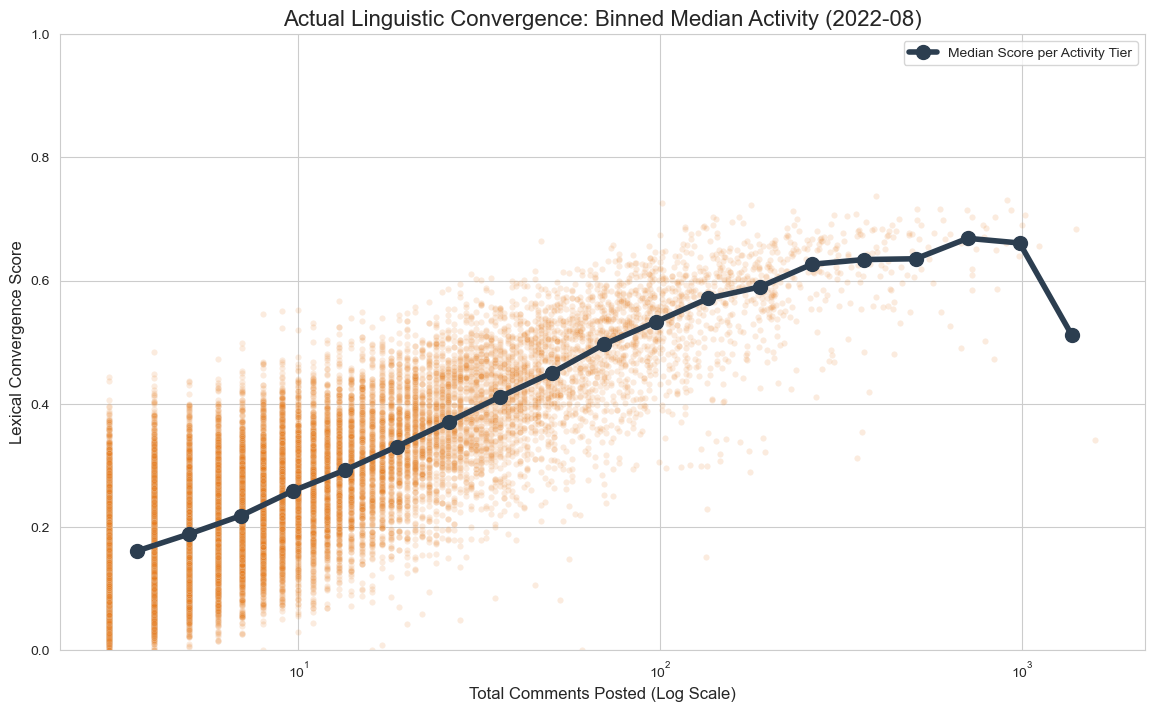

In [204]:
# 1. Create bins for the comment volume (Logarithmic binning)
# This creates bins that get wider as volume increases
bins = np.logspace(np.log10(df_rankings['total_comment_volume'].min()), 
                   np.log10(df_rankings['total_comment_volume'].max()), 20)

df_rankings['bin'] = pd.cut(df_rankings['total_comment_volume'], bins=bins)

# 2. Calculate median score per bin
binned_data = df_rankings.groupby('bin', observed=True)['lexical_score'].median().reset_index()
# Get the midpoint of each bin for plotting
binned_data['bin_mid'] = [b.mid for b in binned_data['bin']]

import utils.visualization as viz
viz.plot_binned_linguistic_gravity(df_rankings, binned_data, TARGET_MONTH)

In [ ]:
thread_str = ",".join([f"'{t}'" for t in all_threads])

# 1. Update the query to include 'score'
query = f"""
    SELECT link_id, author, body as score_body_proxy, score
    FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
    WHERE link_id IN ({thread_str})
"""

# Note: We keep the raw body here to do the aggregation separately if needed, 
# but we must ensure 'score' is in the resulting dataframe.
df_raw_data = con.execute(query).df()

# 2. Merge user weights
df_weighted_impact = df_raw_data.merge(df_rankings[['author', 'insider_weight']], on='author', how='left')

# 3. Calculate "Significant Approval" 
# Ensure we fill NaN weights for authors not in rankings (e.g., deleted users) with a baseline of 0.1
df_weighted_impact['insider_weight'] = df_weighted_impact['insider_weight'].fillna(0.1)

# Now 'score' exists, so this will work:
df_weighted_impact['significant_upvotes'] = df_weighted_impact['score'].clip(lower=0) * df_weighted_impact['insider_weight']

# 4. Grouping by link_id
thread_significance = df_weighted_impact.groupby('link_id').agg(
    total_raw_upvotes=('score', 'sum'),
    weighted_epistemic_impact=('significant_upvotes', 'sum'),
    insider_density=('insider_weight', 'mean')
).reset_index()

import utils.visualization as viz
viz.plot_epistemic_impact(thread_significance)

In [ ]:
# 1. Calculate the "Epistemic Excess"
# We define this as the residual: how much the weighted impact exceeds the simple linear trend
import statsmodels.api as sm

X = thread_significance['total_raw_upvotes']
y = thread_significance['weighted_epistemic_impact']
model = sm.OLS(y, sm.add_constant(X)).fit()
thread_significance['expected_impact'] = model.predict(sm.add_constant(X))
thread_significance['epistemic_excess'] = thread_significance['weighted_epistemic_impact'] - thread_significance['expected_impact']

# 2. Extract the top 10 "Gold Standard" threads
top_excess_threads = thread_significance.sort_values('epistemic_excess', ascending=False).head(10)
thread_ids = top_excess_threads['link_id'].tolist()
thread_str = "'" + "','".join(thread_ids) + "'"

# 3. Pull the content of these high-impact threads
content_query = f"""
    SELECT link_id, author, body, score
    FROM read_json_auto('{COMMENTS_GLOB}', maximum_object_size=50000000, union_by_name=True)
    WHERE link_id IN ({thread_str})
    ORDER BY link_id, score DESC
"""
df_gold_standard = con.execute(content_query).df()

# 4. Print them for your review
for tid in thread_ids:
    print(f"\n{'='*20} THREAD: {tid} {'='*20}")
    print(f"Excess Impact Score: {top_excess_threads[top_excess_threads['link_id'] == tid]['epistemic_excess'].values[0]:.2f}")
    subset = df_gold_standard[df_gold_standard['link_id'] == tid]
    # Print the highest-voted comment in this high-impact thread
    print(f"Top Comment: {subset.iloc[0]['text'][:500]}...")

### 9.9 Epistemic Strategy vs Social Capital

Uses the top "epistemic excess" threads (cell above) as a gold-standard sample. Correlates lexicon dimension counts with upvotes at comment and author level.

**Run order:** epistemic-excess selection → correlation heatmap → author aggregation → power-user scatter grid.

In [ ]:
import re
from epistemic_lexicon import lex
thread_str = ",".join([f"'{t}'" for t in all_threads])
# Build dimension word sets from externalized lexicon (see Section 9.1)
dimensions = {
    name: set(w.lower().replace("_", " ") for w in lex.get(key, []))
    for name, key in [
        ("evidence", "evidence"),
        ("rhetoric", "adversarial"),
        ("hedge", "hedge"),
        ("certainty", "certainty"),
        ("alt_auth", "alt_authority"),
        ("intuitive", "intuitive"),
        ("pattern", "pattern"),
        ("meta", "meta"),
        ("demand", "demand"),
    ]
}
patterns = dimensions  # alias for downstream cells

# Requires `thread_str` from the epistemic-excess cell above
query = f"""
    SELECT author, body, score
    FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
    WHERE link_id IN ({thread_str})
"""
df_raw = con.execute(query).df()

def count_dimension_matches(text, word_set):
    if not isinstance(text, str):
        return 0
    words = set(re.findall(r'\b\w+\b', text.lower()))
    return len(words.intersection(word_set))

for dim_name, word_set in dimensions.items():
    df_raw[f'{dim_name}_count'] = df_raw['text'].apply(lambda x: count_dimension_matches(x, word_set))

corr_matrix = df_raw[[f'{d}_count' for d in dimensions.keys()] + ['score']].corr()

import utils.visualization as viz
viz.plot_epistemic_strategy_correlation(corr_matrix)


In [ ]:
# 1. Aggregate Lexical Dimensions by Author for the Gold Standard Threads
df_commenters = df_raw.groupby('author').agg({
    'score': 'sum', # Total upvotes earned in these threads
    **{f'{name}_count': 'sum' for name in dimensions.keys()}
}).reset_index()

# 2. Normalize to "Dimensions per 100 comments" 
# (Totaling counts per author so we aren't biased by length-per-comment)
for name in dimensions.keys():
    df_commenters[f'{name}_norm'] = df_commenters[f'{name}_count'] 

# 3. Correlation: How does an archetype perform?
corr_matrix_authors = df_commenters[[f'{d}_norm' for d in dimensions.keys()] + ['score']].corr()

# 4. Visualization
import utils.visualization as viz
viz.plot_archetype_performance(df_commenters)

In [ ]:
# 1. & 2. (Keep your existing filtering and scaling logic)
volume_threshold = df_commenters['score'].quantile(0.9) 
df_power_users = df_commenters[df_commenters['score'] >= volume_threshold].copy()

scaler = StandardScaler()
dim_cols = [f'{name}_count' for name in dimensions.keys()]
df_power_users[dim_cols] = scaler.fit_transform(df_power_users[dim_cols])

import utils.visualization as viz
viz.plot_zscore_power_users(df_power_users, dim_cols)

### 9.10 Full-Corpus Scale-Up & Maverick Authority Analysis

This section integrates the massive 21.5-million-row scale-up results. Rather than analyzing a subset of gold-standard threads, we join our staged classification scores (Personal Experience and Procedural Skepticism) with the full Empath baseline lexicons. We also load our localized Maverick Authority entity lift list, which resolves bag-of-words classification limits by performing spaCy NER strictly on predicted trigger spans.

In [ ]:
import pandas as pd
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("=== LOADING FULL-CORPUS CONSTRUCT CORRELATION MATRIX (21.5M rows) ===")
corr_path = 'data/processed/construct_correlation_matrix.csv'
if os.path.exists(corr_path):
    df_corr = pd.read_csv(corr_path, index_col=0)
    display(df_corr[['pe_prob', 'ps_prob', 'evidence_count', 'hedge_count', 'anecdotal_count', 'char_length', 'has_link']])
else:
    print("Correlation matrix CSV not found. Run src/compute_correlation_matrix.py first.")

print("\n=== LOADING FULL-CORPUS ENGAGEMENT REGRESSIONS (21.5M rows) ===")
reg_path = 'data/processed/engagement_regression_results.csv'
if os.path.exists(reg_path):
    df_reg = pd.read_csv(reg_path)
    for name in ['Personal Experience', 'Procedural Skepticism']:
        print(f"\n--- {name.upper()} Decile Summary ---")
        sub = df_reg[df_reg['construct'] == name][['decile', 'min_score', 'max_score', 'median_upvotes', 'mean_upvotes', 'controversiality_rate', 'high_traction_rate', 'count']]
        display(sub)
else:
    print("Regression results CSV not found. Run src/compute_engagement_regression.py first.")

print("\n=== LOADING SPAN-LOCALIZED MAVERICK AUTHORITY ENTITIES (n=108 candidates) ===")
mav_path = 'data/processed/maverick_authority_entities_localized.csv'
if os.path.exists(mav_path):
    df_mav = pd.read_csv(mav_path)
    print("Top 25 Maverick Authority Entities by Lift (min 2 positive mentions):")
    display(df_mav[df_mav['positive_mentions'] >= 2].head(25))
else:
    print("Localized maverick entities CSV not found. Run src/extract_maverick_entities_localized.py first.")

In [24]:
srchsr = '%well.](https://youtu.be/rdrKCilEhC0?t=1313%'

In [21]:
import duckdb

# Get columns directly from a Parquet file
df_info = duckdb.sql(f'''
DESCRIBE SELECT * FROM '{EMPATH}'
''').df()
print(df_info[["column_name", "column_type"]])


            column_name column_type
0                    id     VARCHAR
1                author     VARCHAR
2               upvotes      DOUBLE
3      controversiality      BIGINT
4             parent_id     VARCHAR
5               link_id     VARCHAR
6           created_utc      BIGINT
7           char_length      BIGINT
8              has_link     INTEGER
9                  text     VARCHAR
10       evidence_count     INTEGER
11    adversarial_count     INTEGER
12          hedge_count     INTEGER
13      certainty_count     INTEGER
14  alt_authority_count     INTEGER
15      intuitive_count     INTEGER
16        pattern_count     INTEGER
17           meta_count     INTEGER
18         demand_count     INTEGER
19      anecdotal_count     INTEGER
20   quantitative_count     INTEGER


In [25]:
import duckdb

search_term = srchsr # The % signs are wildcards

query = f"""
    SELECT * 
    FROM '{EMPATH}' 
    WHERE text ILIKE '{search_term}'
"""

# DuckDB filters on disk and only pulls matching rows into memory
filtered_df = duckdb.sql(query).df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [26]:
filtered_df

,id,author,upvotes,controversiality,parent_id,link_id,created_utc,char_length,has_link,text,...,adversarial_count,hedge_count,certainty_count,alt_authority_count,intuitive_count,pattern_count,meta_count,demand_count,anecdotal_count,quantitative_count
0,gre493r,hIXhnWUmMvw,1.0,0,t1_grb06iu,t3_m7fc2c,1616091903,1998,1,"\n[We live in a pretend society.](https://pastebin.com/YPEErwTK)\n\n\n[Is your mind blown how people fall for same thing every time? It shouldn't be. Because divided, singled out individuals has no chance against organized criminal entity; corporation.](https://archive.org/details/TheCorp)\n\nCorporation is an approved scam & spy business. Their approval was obtained through manufactured consent. Corporation is not the industry of manufacturing products. Corporation is in the industry of manufacturing consent.\n\nFree merch > Free speech.\n\n[Corporate, what kind of _free_ manufactured merchandise must be in your goodie bag to consent investing into paradise?](https://archive.org/details/TheCenturyOfSelfThereIsAPolicemanInsideAllOurHeadsepisode3/)\n\nCorporations through governments and vice versa are harvesting our biometric, behavioural data on global scale. So they can get to know us far better than we know ourselves, \nand they not just predict our feelings but also manipulate our feelings and sell us anything they want- Be it a product as a service or politician.\nHave you heard of focus groups? Now with always online/big data collection. You are in focus groups. Except you don't get paid for it. [You get exploited and you pay to be part of it. _Nothing is free, except the energy from the sun, but some get a bill(skin cancer) for that. Thanks to always providing industrial surveillance corporatism._](https://en.wikipedia.org/wiki/Stockholm_syndrome)\n\n[Social credit score indoctrination](https://i.imgur.com/lMDs7gR.png)\n\n[Urge or go well.](https://youtu.be/rdrKCilEhC0?t=1313) \n\n-.-. --- -. ...- . .-. ... . / .-- .. - .... / -.-- --- ..- .-. / -. . .. --. .... -... --- ..- .-. .-.-.-\n\n.--. .-.. . .- ... . / -.. --- / -. --- - / .--. .- .-. - .. -.-. .. .--. .- - . / .. -. / .- / -.-. .. ...- .. .-.. / .-- .- .-. .-.-.-\n\n.- -. -.. / .-. .- - .... . .-. / - .... .. -. -.- / .- -... --- ..- - / .--. . .- -.-. . ..-. ..- .-.. / --. . -. . .-. .- .-.. / ... - .-. .. -.- . .-.-.-",...,0,0,0,0,0,1,0,0,0,0
1,gt266ac,hIXhnWUmMvw,10.0,0,t3_mi0rk7,t3_mi0rk7,1617302457,1998,1,"\n[We live in a pretend society.](https://pastebin.com/YPEErwTK)\n\n\n[Is your mind blown how people fall for same thing every time? It shouldn't be. Because divided, singled out individuals has no chance against organized criminal entity; corporation.](https://archive.org/details/TheCorp)\n\nCorporation is an approved scam & spy business. Their approval was obtained through manufactured consent. Corporation is not the industry of manufacturing products. Corporation is in the industry of manufacturing consent.\n\nFree merch > Free speech.\n\n[Corporate, what kind of _free_ manufactured merchandise must be in your goodie bag to consent investing into paradise?](https://archive.org/details/TheCenturyOfSelfThereIsAPolicemanInsideAllOurHeadsepisode3/)\n\nCorporations through governments and vice versa are harvesting our biometric, behavioural data on global scale. So they can get to know us far better than we know ourselves, \nand they not just predict our feelings but also manipulate our feelings and sell us anything they want- Be it a product as a service or politician.\nHave you heard of focus groups? Now with always online/big data collection. You are in focus groups. Except you don't get paid for it. [You get exploited and you pay to be part of it. _Nothing is free, except the energy from the sun, but some get a bill(skin cancer) for that. Thanks to always providing industrial surveillance corporatism._](https://en.wikipedia.org/wiki/Stockholm_syndrome)\n\n[Social credit score indoctrination](https://i.imgur.com/lMDs7gR.png)\n\n[Urge or go

In [41]:
NER = pd.read_csv('/Users/nash/Projects/ConspiracyComments/data/processed/entity_final_review.csv')

In [42]:
NER.columns

Index(['entity', 'doc_count', 'best_identity', 'wp_description',
       'final_bucket_guess', 'bucket_confidence', 'disambiguation_note',
       'likely_pure_junk', 'dual_purpose_word', 'corpus_example',
       'in_candidate_list', 'final_decision', 'natural_cluster',
       'weak_hint_bucket_guess', 'has_expert_credential',
       'epistemic_authority_kind', 'has_institutional_insider'],
      dtype='object')

In [45]:
NER['final_bucket_guess'].unique()

array(['mainstream_figure_not_source', 'AMBIGUOUS_CLUSTER', nan,
       'maverick_authority', 'AMBIGUOUS_NAME', 'villain',
       'mainstream_source', 'AMBIGUOUS_NAME_PARTITIONED',
       'alternative_source', 'mainstream_expert_authority', 'other'],
      dtype=object)

In [47]:
NER[NER['final_bucket_guess']=='mainstream_expert_authority']

,entity,doc_count,best_identity,wp_description,final_bucket_guess,bucket_confidence,disambiguation_note,likely_pure_junk,dual_purpose_word,corpus_example,in_candidate_list,final_decision,natural_cluster,weak_hint_bucket_guess,has_expert_credential,epistemic_authority_kind,has_institutional_insider
51,Lancet,2310.0,The Lancet,Academic journal,mainstream_expert_authority,reliable_categories,NaN,False,True,"...anchester Royal Infirmary, almost certainly of an immune deficiency. His case was written up in The Lancet of 29 October 1960 by Trevor Stretton, John Leonard (his doctors) and George Williams (the patholog... || ...s repeated with a blind control. Still positive. The doctors went public with a short letter in the Lancet on 7 July 1990. In 1992 Professor David Ho of the Aaron Diamond AIDS Research Centre in New York a... || ...were forced to admit publicly that there was no evidence for this being the first case of HIV/AIDS (Lancet. 347(8995):189, 1996 Jan 20.) They attribute this to errors in the then-new PCR process. However,...",False,NaN,NaN,mainstream_expert_authority,True,formal_credential,False
172,Einstein,1129.0,Albert Einstein,German-born theoretical physicist (1879–1955),mainstream_expert_authority,reliable_categories,NaN,False,False,NaN,False,NaN,NaN,mainstream_expert_authority,True,formal_credential,False
365,Plato,681.0,Plato,Ancient Greek philosopher,mainstream_expert_authority,reliable_categories,NaN,False,False,...Greek verb kubernan which means to steer and was used for the first time in a metaphorical sense by Plato. It then passed on to Latin and then on to many languages.[1] from [http://www.answers.com/topic/g... || Socrates never fucked a boy over twelve. That's not gay. And Plato gave his own name to a form of love: Platonic Love. It means only fucking boys on special occasions... || ...tes never fucked a boy over twelve. That's not gay. And Plato gave his own name to a form of love: Platonic Love. It means only fucking boys on special occasions.,False,NaN,NaN,mainstream_expert_authority,True,formal_credential,False
401,Antony C. Sutton,645.0,Antony C. Sutton,British-American researcher (1925–2002),mainstream_expert_authority,reliable_categories,NaN,False,False,NaN,False,NaN,NaN,mainstream_expert_authority,True,formal_credential,False
434,Dershowitz,611.0,Alan Dershowitz,American lawyer and author (born 1938),mainstream_expert_authority,reliable_categories,NaN,False,False,"...on to take place. Attack the person who *dared* to speak out. Change the subject at all costs. Alan Dershowitz is a master of that tactic. He'll even pull it out when debating a fellow Jew. Pathetic. Here's a... || ...ggy Siegal says Epstein’s two big charitable causes are science** and Israel**. His Brooklyn homies Dershowitz and Rubenstein are also major Israel supporters.](http://nymag.com/news/features/41826/index3.html) || ...m on her sleeve. She has openly consorted and aligned herself with known Zionist traitors like Alan Dershowitz. >But seriously, where do you find this stuff, man? I knew Martillo before I became racially cons...",False,NaN,NaN,mainstream_expert_authority,True,formal_credential,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15760,Christine Grady,20.0,Christine Grady,Nurse-bioethicist and researcher,mainstream_expert_authority,reliable_categories,NaN,False,False,NaN,False,NaN,NaN,mainstream_expert_authority,True,formal_credential,False
15803,Angela Merkel's,20.0,Angela Merkel,Chancellor of Germany from 2005 to 2021,mainstream_expert_authority,reliable_categories,NaN,False,False,"Yes, but why is the MSM focused on Angela Merkel's phone... when we have reliable whistleblowers (who have been proven correct) saying, for example, t... || ...your surveillance mostly useless? Dang, better use all that surveillance for something, how about Angela Merkel's emails, that's gotta be interesting and have some leads to terrorists. Chasing terrorists is just... || ...tag committee dealing

In [35]:
MSM = NER[NER['final_bucket_guess']=="mainstream_source"]

In [36]:
MSM

,entity,doc_count,best_identity,wp_description,final_bucket_guess,bucket_confidence,disambiguation_note,likely_pure_junk,dual_purpose_word,corpus_example,in_candidate_list,final_decision,natural_cluster
15,NBC,3018.0,NBC,American broadcast television network,mainstream_source,reliable_description,NaN,False,False,NaN,False,NaN,NaN
19,IRS,2953.0,Internal Revenue Service,Revenue service of the U.S. federal government,mainstream_source,reliable_description,NaN,False,False,NaN,False,NaN,NaN
23,the Washington Post,2827.0,The Washington Post,American daily newspaper,mainstream_source,reliable_categories,NaN,False,False,NaN,False,NaN,NaN
28,FEMA,2775.0,Federal Emergency Management Agency,United States disaster response agency,mainstream_source,reliable_description,NaN,False,False,NaN,False,NaN,NaN
29,the Federal Reserve,2772.0,Federal Reserve,Central banking system of the US,mainstream_source,weak_hint_single_category,NaN,False,False,"...se he was confused, look at what the caller said: ""I believe if the federal government federalized the federal reserve which is really 12 banks of europe, you can read the information..[names books]... is there any com... || The Federal Reserve is, as the non-U.S. official said, already part of the system of the government. It is partially go... || ...e for the settlement of corporate and municipal securities transactions. The DTCC, a member of the Federal Reserve System, was created in 1999 as a holding company. It has two primary subsidiaries, the Depository...",False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15924,El Paso Intelligence,17.0,El Paso Intelligence Center,Law enforcement agency,mainstream_source,reliable_description,NaN,False,False,NaN,False,NaN,NaN
15932,Executive Intelligence,8.0,Executive Intelligence Review,American LaRouchist magazine,mainstream_source,reliable_categories,NaN,False,False,NaN,False,NaN,NaN
15963,Cleon Skousen,3.0,W. Cleon Skousen,American law enforcement officer and author (1913–2006),mainstream_source,reliable_description,NaN,False,False,NaN,False,NaN,NaN
15969,Alexander Lebedev,3.0,Alexander Lebedev,Russian businessman (born 1959),mainstream_source,weak_hint_single_category,NaN,False,False,NaN,False,NaN,NaN


In [37]:
MA = NER[NER['final_bucket_guess']=='maverick_authority']

In [39]:
MA[:100]

,entity,doc_count,best_identity,wp_description,final_bucket_guess,bucket_confidence,disambiguation_note,likely_pure_junk,dual_purpose_word,corpus_example,in_candidate_list,final_decision,natural_cluster
3,Seth Rich,9139.0,Murder of Seth Rich,"2016 unsolved murder in Washington, D.C., US",maverick_authority,reliable_categories,NaN,False,False,"Debbie Wasserman Schultz today: > “Seth Rich was a dedicated, selfless public servant who worked tirelessly to protect *the most sacred right we... || You misunderstood. I'm saying that Seth Rich may have been involved in voter fraud *for* Clinton and *against* Sanders. Sanders supporters foun... || Are you actually suggesting that Sanders supporters murdered Seth Rich because he helped perpetrate electoral fraud?",False,NaN,NaN
4,Alex Jones,8243.0,Alex Jones,American radio host (born 1974),maverick_authority,reliable_categories,NaN,False,False,"I know how most of reddit feels about anything Alex Jones has to say. But this much is sadly true. >If 125 film stars booked out a hotel, arrived in dark-tin... || Alex Jones was running the exact same story about these plastic coffins in Georgia almost 3 years ago, claimin... || ...ning it's a storage facility for some of their inventory (right next to their manufacturing plant.) Alex Jones was questioned about it on CTC and ate his own words.",True,NaN,NaN
43,QAnon,2511.0,QAnon,American conspiracy theory and political movement,maverick_authority,reliable_categories,NaN,False,False,NaN,False,NaN,NaN
47,Bin Laden,2389.0,Osama bin Laden,Founder of al-Qaeda (1957–2011),maverick_authority,weak_hint_single_category,NaN,False,False,"Right...and lets not forget those fake videos of Bin Laden that were produced.\r Even if the security was lax as you mention...that is still 'inside job-ish' r... || And just a few days before she was murdered, she stated that Bin Laden was dead. Just a coincidence, I'm sure.... || ...es that day and I feel I have to believe the one or two stories I've read about the celebrations by Bin Laden -- even though there's no reason to believe anything the newspaper prints anymore. I also believe...",False,NaN,NaN
93,Breitbart,1747.0,Breitbart News,American news and opinion website,maverick_authority,weak_hint_single_category,NaN,False,False,"The link she is referring to is on Drudge as you know linking to Breitbart who picked up the video from YouTube. The quote from the video is: ""I don't think we're going to b... || ...try by an imperial aggressor, and that America shouldn't gone there in the first place. http://www.breitbart.tv/co-worker-ft-hood-gunman-made-outlandish-comments-condemning-us-foreign-policy/ || ....\r \r My point was that many were calling Robert Fisk's article a ""conspiracy theory"":\r \r http://www.breitbart.com/article.php?id=CNG.ee8e6856c300b312ea0f64a4522381ca.481&show_article=1\r \r http://www.officialwi...",False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2662,Jim Jones,129.0,Jim Jones,American cult leader and mass murderer (1931–1978),maverick_authority,weak_hint_single_category,NaN,False,False,"...Cruise](http://www.youtube.com/watch?v=UFBZ_uAbxS0)'s video for Scientology.) But also people like Jim Jones and Charles Manson... They're not inherently evil and devious, in *their* minds. It's just that the... || Sure. [Aquino](http://www.larouchepub.com/other/2005/3233aquino_profile.html) was like Jim Jones with 1980s tech and a paunch. > After the fall of the Soviet Union, Smirnov moved from military... || ...clopedia as ""Guardians of the Papal Treasure"", meaning that they are Vatican financial agents. 14) Jim Jones of the Jonestown ""Infame"" was a Jesuit. There are photographs showing him wearing the Jesuit cleric...",False,NaN,NaN
2674,Steve Pieczenik,129.0,Steve Pieczenik,American psychiatrist and writer,maverick_authority,reliable_categories,NaN,False,False,"Fascinating inverview. Steve Pieczenik has no doubt that Bin Laden was dead years ago, and the supposed assassination was

In [40]:
NER[NER['entity']=='Graham Hancock']

,entity,doc_count,best_identity,wp_description,final_bucket_guess,bucket_confidence,disambiguation_note,likely_pure_junk,dual_purpose_word,corpus_example,in_candidate_list,final_decision,natural_cluster
625,Graham Hancock,469.0,Graham Hancock,British writer (born 1950),alternative_source,reliable_categories,NaN,False,False,"...f ancient history, it is much easier to understand the open conspiracy. fingerprints of the gods - graham hancock is a good one. secret teachings of all ages. anything along those lines || ...the Gods by Erich von Däniken (he actually has quite a few good books), Fingerprints of the Gods by Graham Hancock (mostly about lost human civilizations/technology but worth a look) or Zechariah Sitchen's works wh... || ...ht want to check him out if you are interested in the subject. Even more relevant to the subject is Graham Hancock who also makes frequent appearances on the show. He is truly convincing on the subject of civilizat...",True,NaN,NaN
